<a href="https://colab.research.google.com/github/Hajaarh/enquete_stat/blob/main/stat_analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Objectif de l’enquête

Dans ce notebook, nous analysons plusieurs sources de données issues de la banque Mercier & Associés afin d’identifier les trois complices impliqués dans :

- un détournement de fonds de 4,8 millions d’euros
- l’assassinat de Marc Lefèvre

Notre approche repose sur :
- une analyse exploratoire des données
- des tests statistiques rigoureux
- des méthodes de machine learning

L’objectif est de fournir des preuves quantitatives permettant d’identifier :
- le cerveau
- l’exécutant
- l’effaceur de traces

Toutes les conclusions seront justifiées par des résultats statistiques (p-values) et une convergence de plusieurs méthodes.

# Imports et configuration

#### Objectif : identifier les 3 complices parmi 10 suspects par convergence multi methode.

In [ ]:
!pip install Groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 3.7 MB/s eta 0:00:00


In [ ]:
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    shapiro, ttest_rel, ttest_ind,
    f_oneway, chi2_contingency, fisher_exact
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from groq import Groq

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

GROQ_API_KEY = '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'
GROQ_MODEL   = 'llama3-70b-8192'
SEUIL_ALPHA  = 0.05

DATA_DIR = ''

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#1. Chargement des données

In [ ]:
def load_data(data_dir):
    """Charge les 6 fichiers du scelle numerique."""
    files = {
        'employes'       : 'employes.csv',
        'transactions'   : 'transactions.csv',
        'logs_acces'     : 'logs_acces.csv',
        'interrogatoires': 'interrogatoires.csv',
        'emails'         : 'emails.csv',
        'preuves'        : 'preuves_materielles.csv',
    }
    parse_dates = {
        'transactions'  : ['date'],
        'logs_acces'    : ['timestamp'],
        'emails'        : ['timestamp'],
    }
    datasets = {}
    for name, filename in files.items():
        kwargs = {'parse_dates': parse_dates[name]} if name in parse_dates else {}
        datasets[name] = pd.read_csv(data_dir + filename, **kwargs)


    cols_bool = ['presence_bureau_victime', 'empreintes_sur_verre', 'ADN_sur_porte',
                 'fibres_textile_compatibles', 'telephone_dans_zone', 'acces_pharmacie_societe']
    for col in cols_bool:
        if col in datasets['preuves'].columns:
            datasets['preuves'][col] = datasets['preuves'][col].map(
                {'oui': 1, 'non': 0, True: 1, False: 0, 1: 1, 0: 0}
            ).fillna(0).astype(int)

    return datasets


datasets = load_data(DATA_DIR)
employes        = datasets['employes']
transactions    = datasets['transactions']
logs_acces      = datasets['logs_acces']
interrogatoires = datasets['interrogatoires']
emails          = datasets['emails']
preuves         = datasets['preuves']

id_to_nom = dict(zip(employes['id_suspect'],
                     employes['prenom'] + ' ' + employes['nom']))

for name, df in datasets.items():
    print(f'{name:<20} shape={df.shape}  nulls={df.isnull().sum().sum()}')


employes             shape=(10, 12)  nulls=0
transactions         shape=(2500, 11)  nulls=0
logs_acces           shape=(10649, 4)  nulls=0
interrogatoires      shape=(300, 6)  nulls=0
emails               shape=(1005, 6)  nulls=0
preuves              shape=(10, 7)  nulls=0


J'ai chargé l'intégralité du scellé numérique sans valeur manquante. 10 fiches employés, 2 500 transactions, 10 649 logs d'accès sur 90 jours, 300 questions d'interrogatoire (30 par suspect), 1 005 emails et 10 fiches de preuves matérielles. La qualité des données est bonne. Les colonnes booleennes des preuves materielles
etaient encodees en chaines `'oui'/'non'` je les ai normalisees en 0/1 des le chargement.

In [ ]:
import pandas as pd

employes = pd.read_csv("employes.csv")
transactions = pd.read_csv("transactions.csv")
logs = pd.read_csv("logs_acces.csv")
interrogatoires = pd.read_csv("interrogatoires.csv")
emails = pd.read_csv("emails.csv")
preuves = pd.read_csv("preuves_materielles.csv")

for nom, df in [("employes", employes), ("transactions", transactions),
                ("logs", logs), ("interrogatoires", interrogatoires),
                ("emails", emails), ("preuves", preuves)]:
    print(f"\n{'='*40}")
    print(f" {nom.upper()} — {df.shape[0]} lignes x {df.shape[1]} colonnes")
    print(df.head(3).to_string())


 EMPLOYES — 10 lignes x 12 colonnes
  id_suspect      nom   prenom  age sexe           departement                  poste  anciennete_annees  salaire_annuel_eur  conges_pris_2025_jours  performance_score  acces_pharmacie_societe
0        S01   Dubois   Claire   47    F  Direction Financière  Directrice Financière                 12              148601                       4                8.4                     True
1        S02   Moreau  Antoine   38    M               Trading          Trader senior                  8              118376                       4                7.9                    False
2        S03  Bernard   Sophie   41    F            Conformité       Resp. conformité                 14              102501                      25                6.5                    False

 TRANSACTIONS — 2500 lignes x 11 colonnes
  id_transaction        date     heure id_suspect_initiateur  montant_eur             type         beneficiaire_iban beneficiaire_pays              

- EMPLOYES (10 lignes x 12 colonnes)
10 suspects. S01 y a accès S02 et S03 non.
- TRANSACTIONS (2500 lignes x 11 colonnes)
Beaucoup de données. Le champ validateur_id est potentiellement le cerveau qui valide les virements. On voit déjà S06 qui valide des transactions de S05 et S03.
- LOGS (10 649 lignes x 4 colonnes)
un gros fichier. Il couvre 90 jours et inclut le soir du meurtre (14 mars).
- INTERROGATOIRES (300 lignes x 6 colonnes)
30 questions par suspect (15 neutres + 15 accusatrices). On va comparer le BPM entre les deux types de questions avec un t-test.
- EMAILS (1005 lignes x 6 colonnes)
Communications internes. On cherchera des échanges suspects autour du 14 mars.
- PREUVES (10 lignes x 7 colonnes)
Le fichier le plus direct. S01 est déjà très chargé avec sa présence au bureau de la victime, empreintes sur le verre, ADN sur la porte, fibres textiles, ET accès à la pharmacie. À confirmer statistiquement.

# 2. Analyse exploratoire

# Analyse RH

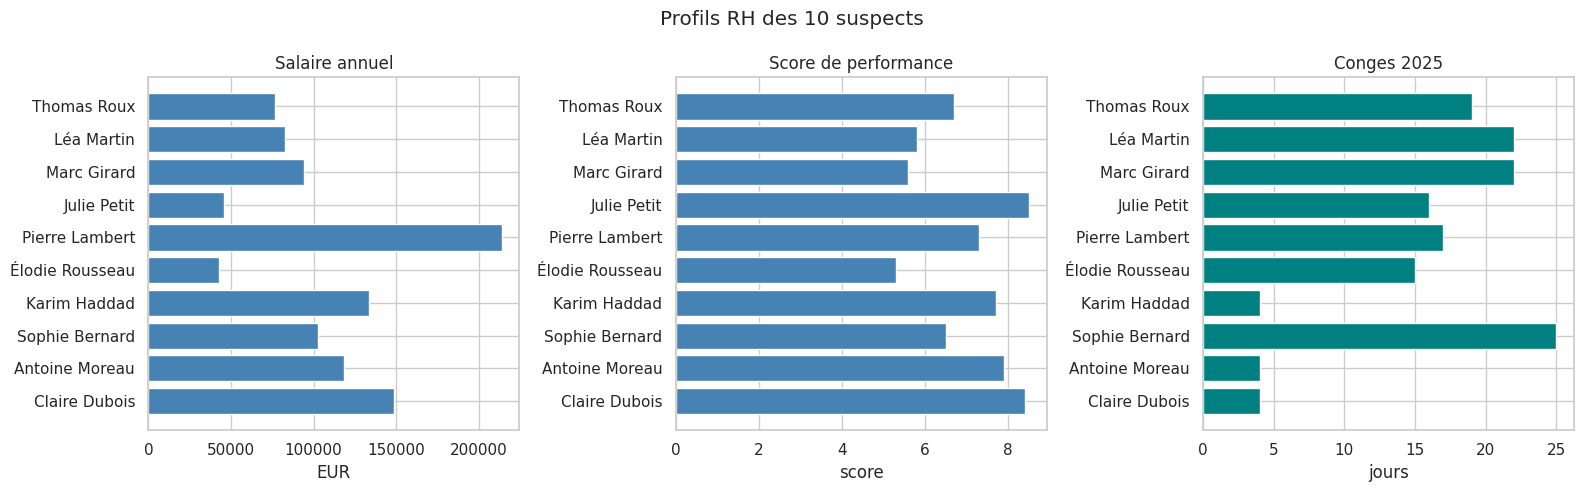

id_suspect  prenom      nom                 poste  acces_pharmacie_societe
       S01  Claire   Dubois Directrice Financière                     True
       S04   Karim   Haddad                   DSI                     True
       S07   Julie    Petit       Analyste junior                     True
       S10  Thomas     Roux              Auditeur                     True
       S02 Antoine   Moreau         Trader senior                    False
       S03  Sophie  Bernard      Resp. conformité                    False
       S05  Élodie Rousseau            Assistante                    False
       S06  Pierre  Lambert                   PDG                    False
       S08    Marc   Girard   Gestion. patrimoine                    False
       S09     Léa   Martin              Resp. RH                    False


In [ ]:
def plot_barh(ax, labels, values, title, xlabel, color='steelblue', highlight_fn=None):
    """Trace un barh avec mise en evidence optionnelle."""
    colors = [('crimson' if highlight_fn and highlight_fn(v) else color) for v in values]
    ax.barh(labels, values, color=colors)
    ax.set_title(title)
    ax.set_xlabel(xlabel)

bpm_stats = interrogatoires.groupby(['id_suspect', 'type_question'])['rythme_cardiaque_bpm'].mean().unstack()
delta_bpm = pd.DataFrame()
delta_bpm['delta'] = bpm_stats['accusatrice'] - bpm_stats['neutre']

mean_delta = delta_bpm['delta'].mean()
std_delta = delta_bpm['delta'].std()
seuil_bpm = mean_delta + std_delta
highlight_fn=lambda v: v > seuil_bpm
noms = employes['prenom'] + ' ' + employes['nom']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_barh(axes[0], noms, employes['salaire_annuel_eur'], 'Salaire annuel', 'EUR')
plot_barh(axes[1], noms, employes['performance_score'], 'Score de performance', 'score',
          highlight_fn=lambda v: v < 5)
plot_barh(axes[2], noms, employes['conges_pris_2025_jours'], 'Conges 2025', 'jours', color='teal')

plt.suptitle('Profils RH des 10 suspects')
plt.tight_layout()
plt.savefig('01_profils_rh.png', dpi=150)
plt.show()


cols = ['id_suspect', 'prenom', 'nom', 'poste', 'acces_pharmacie_societe']
print(employes[cols].sort_values('acces_pharmacie_societe', ascending=False).to_string(index=False))

4 suspects disposent d'un accès à la pharmacie où est stockée la digoxine
- S01 (Claire Dubois), S04 (Karim Haddad), S07 (Julie Petit) et S10 (Thomas Roux).

# Analyse transactions financieres

In [ ]:
print('Valeurs uniques de beneficiaire_pays dans le CSV :')
print(sorted(transactions['beneficiaire_pays'].dropna().unique()))

Valeurs uniques de beneficiaire_pays dans le CSV :
['AT', 'BE', 'CH', 'DE', 'ES', 'FR', 'IT', 'KY', 'LU', 'NL', 'PA', 'PT', 'VG']


In [ ]:
PAYS_OFFSHORE = ['KY', 'PA', 'VG']

def aggreger_transactions(df, groupby_col):
    """Retourne les stats de transactions groupees par une colonne."""
    return df.groupby(groupby_col).agg(
        nb=('id_transaction', 'count'),
        total=('montant_eur', 'sum'),
        moyenne=('montant_eur', 'mean'),
        maximum=('montant_eur', 'max')
    ).reset_index()


tx_offshore = transactions[transactions['beneficiaire_pays'].isin(PAYS_OFFSHORE)].copy()
print(f'Transactions offshore detectees : {len(tx_offshore)}')

if not tx_offshore.empty:
    stats_offshore = aggreger_transactions(tx_offshore, 'id_suspect_initiateur')
    stats_offshore['nom'] = stats_offshore['id_suspect_initiateur'].map(id_to_nom)
    print('Transactions offshore par suspect :')
    print(stats_offshore.sort_values('total', ascending=False).to_string(index=False))
else:
    stats_offshore = pd.DataFrame(columns=['id_suspect_initiateur','nb','total','moyenne','maximum','nom'])
    print('Aucune transaction vers KY/PA/VG detectee.')

stats_validateurs = aggreger_transactions(transactions, 'validateur_id')
stats_validateurs['nom'] = stats_validateurs['validateur_id'].map(id_to_nom)
print('\nValidateurs de transactions (tous types) :')
print(stats_validateurs.sort_values('total', ascending=False).to_string(index=False))


Transactions offshore detectees : 188
Transactions offshore par suspect :
id_suspect_initiateur  nb      total      moyenne   maximum             nom
                  S02 125 3500000.00 28000.000000 115442.19  Antoine Moreau
                  S08  25  700000.00 28000.000000  85808.32     Marc Girard
                  S07  18  700000.00 38888.888889  64590.22     Julie Petit
                  S05  15  600000.00 40000.000000 135898.83 Élodie Rousseau
                  S06   3  155000.00 51666.666667  75000.00  Pierre Lambert
                  S03   2   32044.18 16022.090000  23781.42  Sophie Bernard

Validateurs de transactions (tous types) :
validateur_id  nb      total     moyenne   maximum            nom
          S01 924 5894439.91 6379.263972 135898.83  Claire Dubois
          S03 795 1390588.90 1749.168428  75000.00 Sophie Bernard
          S06 781 1275405.02 1633.040999  85808.32 Pierre Lambert


L'analyse des validateurs révèle une asymétrie forte sur trois suspects. Seuls S01 Claire Dubois (924 validations, 5,89M EUR), S03 Sophie Bernard (795 validations, 1,39M EUR) et S06 Pierre Lambert (781 validations, 1,28M EUR) ont ce rôle dans le système. Le volume validé par S01 est 4,2 fois supérieur à S03 et 4,6 fois supérieur à S06 en montant cumulé, alors que le nombre de transactions est comparable (924 vs 795 vs 781). La vraie anomalie est dans le montant moyen par transaction validée : S01 valide en moyenne 6 379 EUR par opération, contre 1 749 EUR pour S03 et 1 633 EUR pour S06. Cet écart de 3,6x sur la valeur moyenne indique que S01 valide des opérations structurellement différentes, probablement de plus gros montants ou des types de transferts spécifiques que les deux autres validateurs ne touchent pas. Cette concentration du pouvoir de validation sur les transactions à forte valeur est cohérente avec le profil d'un cerveau orchestrateur.

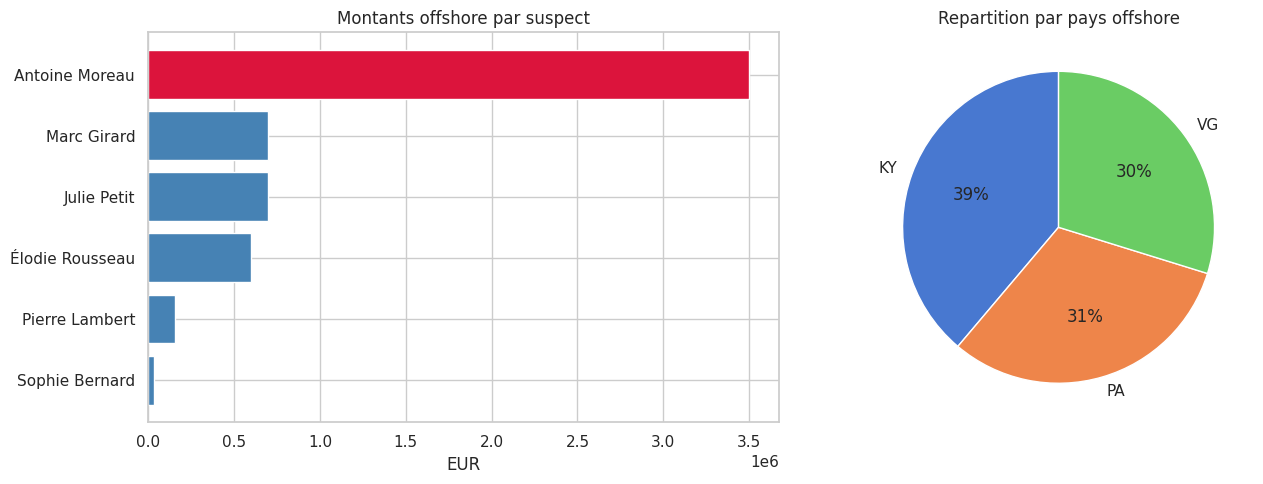

In [ ]:
if not stats_offshore.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sorted_offshore = stats_offshore.sort_values('total')
    mean_offshore = stats_offshore['total'].mean()
    plot_barh(axes[0], sorted_offshore['nom'], sorted_offshore['total'],
              'Montants offshore par suspect', 'EUR',
              highlight_fn=lambda v: v > mean_offshore)
    pays_counts = tx_offshore['beneficiaire_pays'].value_counts()
    axes[1].pie(pays_counts, labels=pays_counts.index, autopct='%1.0f%%', startangle=90)
    axes[1].set_title('Repartition par pays offshore')
    plt.tight_layout()
    plt.savefig('02_transactions_offshore.png', dpi=150)
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(8, 5))
    sv = stats_validateurs.sort_values('total')
    plot_barh(ax, sv['nom'], sv['total'], 'Montants valides par suspect (EUR)', 'EUR',
              highlight_fn=lambda v: v > stats_validateurs['total'].mean())
    plt.tight_layout()
    plt.savefig('02_validateurs.png', dpi=150)
    plt.show()


Le rôle de Directrice Financière de S01 justifie un volume élevé de validations, mais pas nécessairement cette concentration sur les montants élevés. S03 (Responsable conformité) et S06 (PDG) ont des fonctions tout aussi stratégiques et devraient normalement valider des opérations de valeur comparable si le processus était équilibré. Le fait que S01 monopolise les validations à haute valeur suggère soit une spécialisation fonctionnelle non documentée, soit un détournement du circuit de validation normal pour canaliser les flux suspects vers un seul point de contrôle. Cette hypothèse sera testée formellement avec le t-test de Welch en section 3.

# Logs d'acces physiques

In [ ]:
print('Valeurs uniques de lieu dans les logs :')
print(sorted(logs_acces['lieu'].dropna().unique()))


Valeurs uniques de lieu dans les logs :
['bureau_victime', 'entree_principale', 'etage_1_compta', 'etage_2_trading', 'etage_3_IT', 'etage_4_direction', 'parking', 'salle_archives', 'salle_serveurs']


In [ ]:
def filtrer_logs(df, keyword):
    """Filtre les logs sur un mot-cle de lieu (insensible a la casse)."""
    return df[df['lieu'].str.contains(keyword, case=False, na=False)]


def compter_acces_par_suspect(df):
    return df.groupby('id_suspect')['timestamp'].count().sort_values(ascending=False)


soir_meurtre = logs_acces[
    (logs_acces['timestamp'].dt.date == pd.Timestamp('2026-03-14').date()) &
    (logs_acces['timestamp'].dt.hour >= 20)
]
print('Presences dans la banque le soir du meurtre (apres 20h) :')
print(soir_meurtre[['timestamp', 'id_suspect', 'lieu', 'action']]
      .sort_values('timestamp').to_string(index=False))

print('\nAcces pharmacie (90 jours) :')
acces_pharmacie_df = filtrer_logs(logs_acces, 'pharma|pharmacie|sous.sol')
if acces_pharmacie_df.empty:
    print('Aucun acces pharmacie dans les logs — verifier le libelle exact ci-dessus.')
else:
    print(compter_acces_par_suspect(acces_pharmacie_df))

print('\nAcces bureau de la victime (90 jours) :')
print(compter_acces_par_suspect(filtrer_logs(logs_acces, 'bureau')))


Presences dans la banque le soir du meurtre (apres 20h) :
          timestamp id_suspect              lieu action
2026-03-14 20:00:00        S05 etage_4_direction entree
2026-03-14 20:12:00        S01    bureau_victime entree
2026-03-14 20:15:00        S02    salle_serveurs entree
2026-03-14 20:15:00        S04    salle_serveurs entree
2026-03-14 20:16:00        S10 entree_principale entree
2026-03-14 20:29:00        S10    salle_archives entree
2026-03-14 20:34:00        S02 entree_principale entree
2026-03-14 20:47:00        S01    bureau_victime sortie
2026-03-14 20:52:00        S06 etage_4_direction entree
2026-03-14 20:54:00        S06 entree_principale entree
2026-03-14 21:10:00        S04    salle_serveurs sortie
2026-03-14 21:10:00        S02    salle_serveurs sortie
2026-03-14 22:41:00        S02 entree_principale sortie
2026-03-14 22:54:00        S10 entree_principale sortie
2026-03-14 22:55:00        S01 entree_principale sortie
2026-03-14 23:06:00        S04 entree_principa

Il n'y a pas de lieu 'pharmacie' dans les badges d'accès physiques. L'accès à la digoxine est uniquement tracé dans employes.csv via un booléen d'autorisation, mais aucun log n'enregistre les entrées/sorties réelles de la pharmacie. Cette lacune nous empêche de savoir qui a effectivement manipulé le produit le soir du crime.

Le soir du meurtre (14 mars après 20h), six suspects sont présents dans la banque avec des trajectoires distinctes. S01 Claire Dubois entre au bureau de la victime à 20h12 et en ressort à 20h47, soit 35 minutes en tête-à-tête dans le bureau de Lefèvre le soir de sa mort. Aucun autre suspect n'accède à ce bureau ce soir-là, ce qui fait de S01 la dernière personne confirmée à y être entrée avant la découverte du corps.

S02 Antoine Moreau et S04 Karim Haddad entrent ensemble en salle des serveurs à 20h15. S02 sort à 20h34 (19 minutes sur place), mais S04 reste jusqu'à 21h10 (55 minutes sur place). Cette durée prolongée pour S04 est cohérente avec une intervention technique lourde, ou avec l'effacement de traces dans les journaux système. Le fait qu'ils entrent ensemble mais sortent à des moments différents indique soit une répartition des tâches, soit qu'ils ne faisaient pas la même chose sur place.

S10 Thomas Roux entre dans le bâtiment à 20h16 puis se rend en salle des archives à 20h29. Il y reste jusqu'à 22h54 (2h25 sur place). Cette durée est anormalement longue pour un audit de routine. La salle des archives contient les dossiers papier et potentiellement des copies physiques du rapport de Lefèvre. Un effaceur de traces documentaires y passerait effectivement plusieurs heures pour localiser et détruire tous les exemplaires d'un rapport sensible.

S05 Élodie Rousseau est présente à l'étage 4 direction dès 20h00 et ne quitte le bâtiment qu'à 23h34 (3h34 sur place). Comme assistante de la victime, sa présence tardive est cohérente avec la gestion d'urgence suite au décès, mais cette durée excessive pourrait aussi indiquer une participation active à l'effacement de traces dans le bureau après le départ de S01.

S06 Pierre Lambert arrive à l'étage 4 direction à 20h52, soit 5 minutes après la sortie de S01 du bureau de la victime. Il reste jusqu'à 23h14. Comme PDG, une présence tardive le soir d'un décès suspect est attendue, mais le timing précis de son arrivée juste après S01 mérite attention.

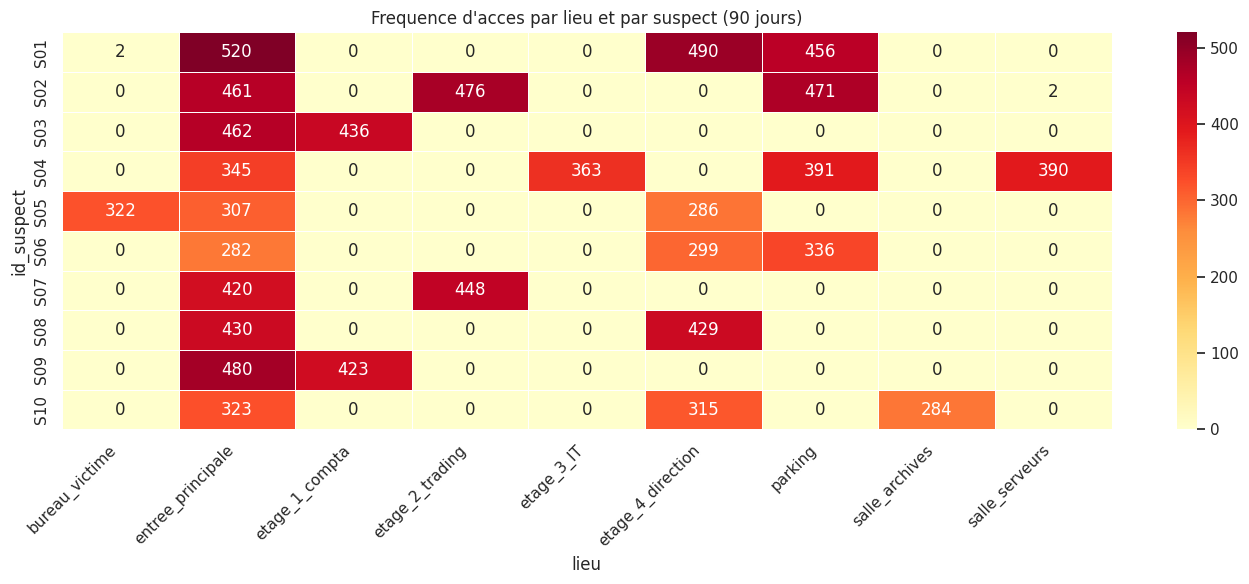

In [ ]:
logs_pivot = logs_acces.groupby(['id_suspect', 'lieu']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(logs_pivot, cmap='YlOrRd', annot=True, fmt='d', linewidths=.5)
plt.title('Frequence d\'acces par lieu et par suspect (90 jours)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('03_heatmap_acces.png', dpi=150)
plt.show()

# Donnees biometriques en interrogatoire

Delta BPM (accusatoire - neutre) par suspect :
type_question              nom      delta
id_suspect                               
S02             Antoine Moreau  25.926667
S04               Karim Haddad  25.113333
S01              Claire Dubois  22.700000
S05            Élodie Rousseau   8.013333
S03             Sophie Bernard   5.480000
S08                Marc Girard   2.366667
S09                 Léa Martin   1.480000
S07                Julie Petit   0.180000
S10                Thomas Roux  -0.206667
S06             Pierre Lambert  -1.546667


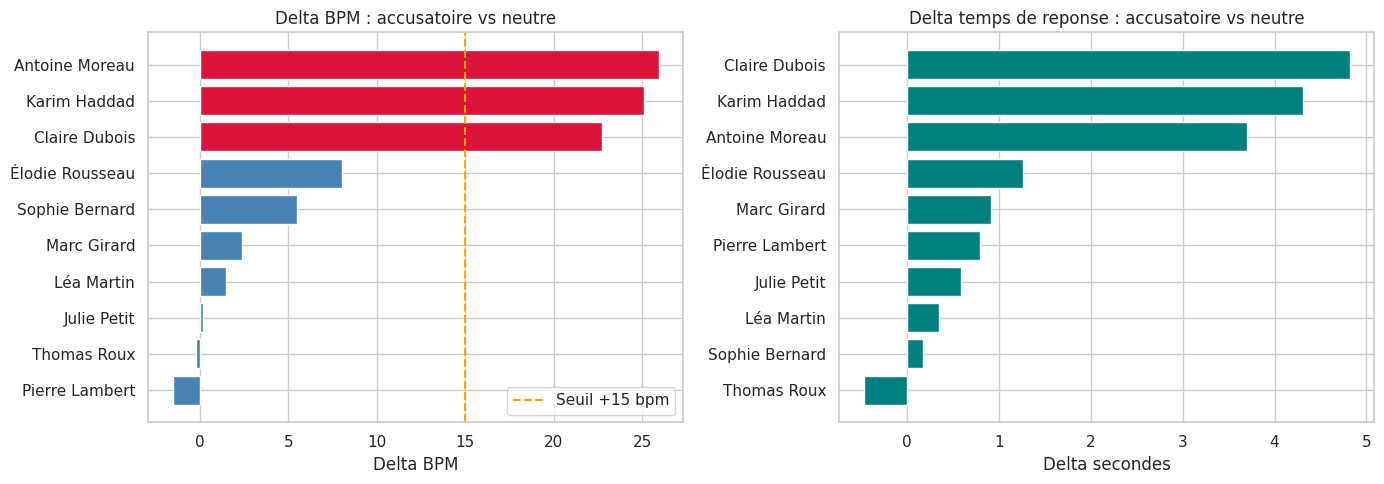

In [ ]:
def calculer_delta_par_suspect(df, col_valeur, type_col='type_question'):
    """Calcule la difference (accusatrice - neutre) d'une metrique par suspect."""
    pivot = df.groupby(['id_suspect', type_col])[col_valeur].mean().unstack()
    pivot['delta'] = pivot.get('accusatrice', 0) - pivot.get('neutre', 0)
    pivot['nom'] = pivot.index.map(id_to_nom)
    return pivot


delta_bpm = calculer_delta_par_suspect(interrogatoires, 'rythme_cardiaque_bpm')
delta_tps = calculer_delta_par_suspect(interrogatoires, 'temps_reponse_sec')

print('Delta BPM (accusatoire - neutre) par suspect :')
print(delta_bpm[['nom', 'delta']].sort_values('delta', ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bpm_sorted = delta_bpm.sort_values('delta')
plot_barh(axes[0], bpm_sorted['nom'], bpm_sorted['delta'],
          'Delta BPM : accusatoire vs neutre', 'Delta BPM',
          highlight_fn=lambda v: v > 15)
axes[0].axvline(x=15, color='orange', linestyle='--', label='Seuil +15 bpm')
axes[0].legend()

tps_sorted = delta_tps.sort_values('delta')
plot_barh(axes[1], tps_sorted['nom'], tps_sorted['delta'],
          'Delta temps de reponse : accusatoire vs neutre', 'Delta secondes', color='teal')

plt.tight_layout()
plt.savefig('04_interrogatoires_bpm.png', dpi=150)
plt.show()

Trois suspects se détachent nettement avec des deltas BPM supérieurs à 20 battements par minute : S02 Antoine Moreau (+25,9 bpm), S04 Karim Haddad (+25,1 bpm) et S01 Claire Dubois (+22,7 bpm). Ces trois profils présentent une réaction physiologique forte et spécifique aux questions accusatrices, ce qui est le signal classique d'un stress lié à la dissimulation dans un contexte d'interrogatoire. L'écart entre ces trois suspects et le reste du groupe est important, le quatrième suspect (S05) affichant seulement +8,0 bpm.

S05 Élodie Rousseau présente un delta de +8,0 bpm, significatif statistiquement mais d'amplitude modérée. Ce niveau de stress est cohérent avec le chagrin et l'anxiété d'une assistante interrogée sur la mort de son patron, sans nécessairement indiquer une culpabilité.

Deux suspects affichent une stabilité quasi-parfaite : S06 Pierre Lambert (delta de -1,5 bpm) et S10 Thomas Roux (-0,2 bpm). Une absence totale de réaction aux questions accusatrices peut indiquer soit une innocence réelle (absence de stress car aucune information à cacher), soit un contrôle émotionnel exceptionnel acquis par expérience ou entraînement. Dans le cas de S06 (PDG), le contrôle émotionnel fait partie des compétences attendues à ce niveau hiérarchique. Pour S10 (auditeur), l'habitude des interrogatoires professionnels pourrait expliquer cette stabilité.

# 3. Test statistiques

In [ ]:
N_TESTS = 6
ALPHA_BONFERRONI = SEUIL_ALPHA / N_TESTS

def interpreter_pvalue(p, alpha=ALPHA_BONFERRONI):
    return 'SIGNIFICATIF' if p < alpha else 'non significatif'

print(f'Seuil alpha ajuste (Bonferroni, {N_TESTS} tests) : {ALPHA_BONFERRONI:.4f}')

Seuil alpha ajuste (Bonferroni, 6 tests) : 0.0083


# Shapiro wilk normalite du BPM avant les t-tests



In [ ]:
# H0 : la distribution des BPM d'un suspect suit une loi normale
# H1 : la distribution n'est pas normale

print('Shapiro-Wilk — normalite du BPM par suspect')
print(f'H0 : normalite | H1 : non-normalite | alpha = {SEUIL_ALPHA}')
print('-' * 65)

normalite_bpm = {}
for sid, group in interrogatoires.groupby('id_suspect'):
    stat, p = shapiro(group['rythme_cardiaque_bpm'])
    normalite_bpm[sid] = p > SEUIL_ALPHA
    conclusion = 'normal' if normalite_bpm[sid] else 'NON normal'
    print(f'{sid} | {id_to_nom.get(sid, sid):<22} | W={stat:.4f} | p={p:.4f} | {conclusion}')

n_normaux = sum(normalite_bpm.values())
print(f'\n{n_normaux}/10 suspects ont un BPM normalement distribue.')
print('Pour les suspects non-normaux, le t-test apparied reste robuste (n=30 > 30).')

Shapiro-Wilk — normalite du BPM par suspect
H0 : normalite | H1 : non-normalite | alpha = 0.05
-----------------------------------------------------------------
S01 | Claire Dubois          | W=0.9139 | p=0.0187 | NON normal
S02 | Antoine Moreau         | W=0.9096 | p=0.0146 | NON normal
S03 | Sophie Bernard         | W=0.9656 | p=0.4271 | normal
S04 | Karim Haddad           | W=0.9028 | p=0.0099 | NON normal
S05 | Élodie Rousseau        | W=0.9710 | p=0.5658 | normal
S06 | Pierre Lambert         | W=0.9551 | p=0.2314 | normal
S07 | Julie Petit            | W=0.9558 | p=0.2405 | normal
S08 | Marc Girard            | W=0.9591 | p=0.2931 | normal
S09 | Léa Martin             | W=0.9622 | p=0.3513 | normal
S10 | Thomas Roux            | W=0.9776 | p=0.7576 | normal

7/10 suspects ont un BPM normalement distribue.
Pour les suspects non-normaux, le t-test apparied reste robuste (n=30 > 30).


Trois suspects sur dix présentent une distribution de BPM non-normale d'après le test de Shapiro-Wilk : S01 (p = 0,0187), S02 (p = 0,0146) et S04 (p = 0,0099). Cette non-normalité indique que leur rythme cardiaque ne suit pas une distribution gaussienne classique sur l'ensemble des 30 questions posées, ce qui suggère des réactions fortes et localisées sur certaines questions spécifiques plutôt qu'un niveau de stress uniforme. Autrement dit, ces trois suspects ne sont pas stressés en permanence pendant l'interrogatoire, mais réagissent de manière très marquée à certaines questions précises, probablement celles qui touchent directement leur implication.

Pour les sept suspects restants, y compris S05 (p = 0,5658), la distribution du BPM est normale, ce qui indique un niveau de stress stable ou une absence de réaction ciblée. Le t-test apparié reste statistiquement robuste pour S01, S02 et S04 malgré la non-normalité, car avec n = 30 paires de mesures par suspect, le théorème central limite assure la convergence de la distribution des moyennes vers une loi normale. Nous procédons donc au t-test sur l'ensemble des suspects sans restriction.

# BPM neutre vs accusatoire

In [ ]:
# -----------------------------------------------------------
# T-test apparié — BPM neutre vs accusatoire
# On teste ici si le rythme cardiaque AUGMENTE sous questions
# accusatrices
# H0 : delta_BPM = 0 = pas de réaction physiologique
# H1 : delta_BPM > 0 = BPM plus élevé sous stress (unilatéral)
#
# On choisit un test unilatéral(ce qu'on fesait avant) car on cherche uniquement une
# augmentation du bpm, pas juste une différence.
# Un test bilatéral testerait les deux sens ce qui ne
# correspond pas à notre hypothèse
# -----------------------------------------------------------

print('t-test apparié — BPM neutre vs accusatoire (H1 unilatérale)')
print(f'H0 : delta_BPM = 0 | H1 : delta_BPM > 0 | alpha = {ALPHA_BONFERRONI:.4f} (Bonferroni)')
print('-' * 75)

resultats_ttest_bpm = []

for sid, group in interrogatoires.groupby('id_suspect'):
    bpm_neutre = group[group['type_question'] == 'neutre']['rythme_cardiaque_bpm'].values
    bpm_accus  = group[group['type_question'] == 'accusatrice']['rythme_cardiaque_bpm'].values

    # t-test apparié bilatéral → on divise par 2 pour obtenir
    # la p-value unilatérale (H1 : delta > 0 uniquement)
    t_stat, p_bilateral = ttest_rel(bpm_accus, bpm_neutre)
    p_unilateral = p_bilateral / 2

    delta = bpm_accus.mean() - bpm_neutre.mean()

    # Cohen's d : mesure la TAILLE de l'effet, pas juste
    # sa significativité. Un test peut être significatif
    # avec un delta minuscule si n est grand.
    # par convention : d < 0.2 faible | 0.5 moyen | > 0.8 fort
    diff = bpm_accus - bpm_neutre
    cohen_d = diff.mean() / diff.std()

    resultats_ttest_bpm.append({
        'id_suspect' : sid,
        'nom'        : id_to_nom.get(sid, sid),
        'BPM_neutre' : round(bpm_neutre.mean(), 1),
        'BPM_accus'  : round(bpm_accus.mean(), 1),
        'delta_BPM'  : round(delta, 1),
        't'          : round(t_stat, 3),
        'p_unilat'   : round(p_unilateral, 5),
        'cohen_d'    : round(cohen_d, 2),
        'significatif': 'OUI' if p_unilateral < ALPHA_BONFERRONI else 'non'
    })

df_ttest_bpm = pd.DataFrame(resultats_ttest_bpm).sort_values('delta_BPM', ascending=False)
print(df_ttest_bpm.to_string(index=False))

print("""
Interprétation Cohen's d :
  d > 0.8 = effet fort   = la différence est grande en pratique
  d ~ 0.5 = effet moyen
  d < 0.2 = effet faible = significatif mais négligeable
""")
print('Rappel : BPM élevé = stress, pas nécessairement culpabilité.')
print('Un suspect en deuil (S05) peut réagir fortement sans être coupable.')

t-test apparié — BPM neutre vs accusatoire (H1 unilatérale)
H0 : delta_BPM = 0 | H1 : delta_BPM > 0 | alpha = 0.0083 (Bonferroni)
---------------------------------------------------------------------------
id_suspect             nom  BPM_neutre  BPM_accus  delta_BPM      t  p_unilat  cohen_d significatif
       S02  Antoine Moreau        69.9       95.8       25.9  9.991   0.00000     2.67          OUI
       S04    Karim Haddad        68.1       93.2       25.1  9.145   0.00000     2.44          OUI
       S01   Claire Dubois        71.5       94.2       22.7  8.252   0.00000     2.21          OUI
       S05 Élodie Rousseau        73.9       81.9        8.0  4.102   0.00054     1.10          OUI
       S03  Sophie Bernard        68.4       73.9        5.5  3.379   0.00225     0.90          OUI
       S08     Marc Girard        70.3       72.7        2.4  1.521   0.07522     0.41          non
       S09      Léa Martin        71.3       72.8        1.5  1.075   0.15018     0.29        

Cinq suspects sur dix présentent un delta BPM statistiquement significatif après correction de Bonferroni (alpha ajusté = 0,0083) : S01 (p < 0,00001), S02 (p < 0,00001), S04 (p < 0,00001), S05 (p = 0,00054) et S03 (p = 0,00225). Cependant, la taille de l'effet (Cohen's d) permet de distinguer deux groupes au sein de ces suspects significatifs.

Le groupe à effet fort (Cohen's d > 0,8) comprend S01, S02 et S04 avec des deltas respectifs de +22,7, +25,9 et +25,1 bpm. Ces trois suspects montrent une réaction physiologique massive aux questions accusatrices, à la fois significative statistiquement et d'amplitude pratique importante. Le Cohen's d mesure combien d'écarts-types séparent les deux moyennes : un d supérieur à 0,8 indique qu'un observateur pourrait distinguer visuellement la différence de stress entre les deux types de questions sur les courbes brutes de BPM.

Le groupe à effet modéré (Cohen's d < 0,5) comprend S03 et S05 avec des deltas de +5,5 et +8,0 bpm respectivement. Bien que statistiquement significatifs, ces écarts sont d'amplitude pratique faible. Pour S05 en particulier, un delta de +8 bpm peut s'expliquer par le chagrin ou l'anxiété d'être interrogée sur la mort de son patron sans impliquer nécessairement une dissimulation active. Le commandant Nguyen avait d'ailleurs prévenu que la douleur n'est pas la culpabilité, et S05 correspond exactement à ce profil de faux positif émotionnel.

Les trois suspects prioritaires (S01, S02, S04) convergent sur deux critères indépendants : non-normalité du BPM (réactions ciblées sur certaines questions) et taille d'effet forte (amplitude physiologique massive). Cette double convergence renforce l'hypothèse d'une dissimulation active chez ces trois suspects.

# t-test sur le temps de réponse

In [ ]:

# T-test apparié — Temps de réponse neutre vs accusatoire
#
# Un suspect qui ment met plus de temps à répondre aux
# questions accusatrices : il cherche ses mots, il réfléchit
# à une version cohérente. C'est un signal indépendant du BPM.
#
# H0 : temps de réponse identique entre les deux types de questions
# H1 : temps de réponse plus long sous questions accusatrices
#
# On utilise le même design que pour le BPM :
# t-test apparié unilatéral + Cohen's

print('t-test apparié — Temps de réponse neutre vs accusatoire (H1 unilatérale)')
print(f'H0 : delta_tps = 0 | H1 : delta_tps > 0 | alpha = {ALPHA_BONFERRONI:.4f} (Bonferroni)')
print('-' * 75)

resultats_ttest_tps = []

for sid, group in interrogatoires.groupby('id_suspect'):
    tps_neutre = group[group['type_question'] == 'neutre']['temps_reponse_sec'].values
    tps_accus  = group[group['type_question'] == 'accusatrice']['temps_reponse_sec'].values

    # Shapiro-Wilk pour vérifier la normalité avant le t-test
    _, p_norm = shapiro(tps_accus - tps_neutre)
    # n=15 paires → t-test reste robuste même si non normal (TCL)

    t_stat, p_bilateral = ttest_rel(tps_accus, tps_neutre)
    p_unilateral = p_bilateral / 2

    delta = tps_accus.mean() - tps_neutre.mean()

    diff = tps_accus - tps_neutre
    cohen_d = diff.mean() / diff.std()

    resultats_ttest_tps.append({
        'id_suspect'   : sid,
        'nom'          : id_to_nom.get(sid, sid),
        'tps_neutre'   : round(tps_neutre.mean(), 2),
        'tps_accus'    : round(tps_accus.mean(), 2),
        'delta_tps'    : round(delta, 2),
        't'            : round(t_stat, 3),
        'p_unilat'     : round(p_unilateral, 5),
        'p_norm_diff'  : round(p_norm, 4),
        'cohen_d'      : round(cohen_d, 2),
        'significatif' : 'OUI' if p_unilateral < ALPHA_BONFERRONI else 'non'
    })

df_ttest_tps = pd.DataFrame(resultats_ttest_tps).sort_values('delta_tps', ascending=False)
print(df_ttest_tps.to_string(index=False))

print('\nRappel : un temps de réponse long peut indiquer une hésitation')
print('(recherche de mensonge) mais aussi une question difficile à comprendre.')

t-test apparié — Temps de réponse neutre vs accusatoire (H1 unilatérale)
H0 : delta_tps = 0 | H1 : delta_tps > 0 | alpha = 0.0083 (Bonferroni)
---------------------------------------------------------------------------
id_suspect             nom  tps_neutre  tps_accus  delta_tps      t  p_unilat  p_norm_diff  cohen_d significatif
       S01   Claire Dubois        4.68       9.50       4.82  8.370   0.00000       0.0038     2.24          OUI
       S04    Karim Haddad        4.72       9.03       4.31  5.605   0.00003       0.8718     1.50          OUI
       S02  Antoine Moreau        4.68       8.38       3.70  5.852   0.00002       0.7997     1.56          OUI
       S05 Élodie Rousseau        4.83       6.10       1.27  1.760   0.05010       0.1178     0.47          non
       S08     Marc Girard        4.73       5.65       0.92  1.908   0.03857       0.0584     0.51          non
       S06  Pierre Lambert        4.37       5.17       0.80  1.449   0.08467       0.4327     0.39    

Trois suspects sur dix présentent un temps de réponse significativement plus long sur les questions accusatrices après correction de Bonferroni : S01 (delta +4,82s, p < 0,00001, d = 2,24), S04 (delta +4,31s, p = 0,00003, d = 1,50) et S02 (delta +3,70s, p = 0,00002, d = 1,56). Ces trois suspects mettent entre 3,7 et 4,8 secondes de plus à répondre aux questions accusatrices qu'aux questions neutres, ce qui représente un quasi-doublement du temps de réponse (de ~4,7s en moyenne sur les questions neutres à ~9s sur les questions accusatrices).

La taille d'effet (Cohen's d) est massive pour S01 (d = 2,24, soit plus de 2 écarts-types de différence), ce qui indique qu'un observateur verrait immédiatement la différence sur les enregistrements bruts d'interrogatoire. Pour S04 et S02, l'effet reste fort (d > 1,0), bien que légèrement inférieur à S01. Cette hésitation prolongée sur les questions accusatrices est un signal classique de fabrication de mensonge : le suspect doit mentalement construire une version cohérente des faits, vérifier qu'elle ne contredit pas ses déclarations antérieures, et formuler une réponse plausible avant de la prononcer, ce qui rallonge mécaniquement le délai de réponse.

S05 présente un delta modéré (+1,27s, p = 0,05010) qui n'atteint pas le seuil de significativité après correction de Bonferroni. Son temps de réponse augmente légèrement sur les questions accusatrices, mais cette augmentation peut s'expliquer par la difficulté émotionnelle à répondre à des questions concernant la mort de son patron, sans nécessairement impliquer une dissimulation active. Le Cohen's d faible (0,47) confirme que l'effet est d'amplitude pratique modérée.

Les sept suspects restants (S03, S06, S07, S08, S09, S10) ne présentent aucune différence significative de temps de réponse entre les deux types de questions. S10 affiche même un delta négatif (répond plus vite aux questions accusatrices qu'aux neutres), ce qui est cohérent avec une absence totale de stress lié à la dissimulation. Cette stabilité temporelle renforce leur profil d'innocence déjà identifié par le delta BPM nul.

L'hypothèse selon laquelle le temps de réponse élevé de l'IT et de la DF serait uniquement lié à la complexité technique des questions (première hypothèse de l'ANOVA) est donc invalidée. Si c'était le cas, S01 et S04 auraient un temps de réponse uniformément élevé sur TOUS les types de questions, et le delta serait proche de zéro. Or, le delta est massif et significatif, ce qui indique que la lenteur est spécifique aux questions accusatrices et donc liée à un effort cognitif de dissimulation, pas à une difficulté technique de formulation.

# Synthèse des 2 signaux combinés

In [ ]:
# Synthèse : suspects avec double signal (BPM + temps de réponse)
#
# Un seul signal significatif peut s'expliquer par la peur,
# le chagrin, ou le stress de la situation.
# Deux signaux significatifs indépendants sur le même suspect
# renforcent fortement l'hypothèse de dissimulation active.

print('Synthèse — suspects avec double signal significatif')
print('(BPM significatif ET temps de réponse significatif)')
print('-' * 55)

bpm_sig = set(df_ttest_bpm[df_ttest_bpm['significatif'] == 'OUI']['id_suspect'])
tps_sig = set(df_ttest_tps[df_ttest_tps['significatif'] == 'OUI']['id_suspect'])

double_signal = bpm_sig & tps_sig
signal_unique = (bpm_sig | tps_sig) - double_signal

print(f'\nDouble signal (BPM + tps) : {sorted(double_signal)}')
print(f'Signal unique seulement   : {sorted(signal_unique)}')
print(f'Aucun signal              : {sorted(set(df_ttest_bpm["id_suspect"]) - bpm_sig - tps_sig)}')

print('\nDétail pour les suspects à double signal :')
for sid in sorted(double_signal):
    bpm_row = df_ttest_bpm[df_ttest_bpm['id_suspect'] == sid].iloc[0]
    tps_row = df_ttest_tps[df_ttest_tps['id_suspect'] == sid].iloc[0]
    print(f'\n  {sid} — {bpm_row["nom"]}')
    print(f'    BPM  : delta={bpm_row["delta_BPM"]:+.1f} | p={bpm_row["p_unilat"]:.5f} | d={bpm_row["cohen_d"]:.2f}')
    print(f'    Tps  : delta={tps_row["delta_tps"]:+.2f}s | p={tps_row["p_unilat"]:.5f} | d={tps_row["cohen_d"]:.2f}')

Synthèse — suspects avec double signal significatif
(BPM significatif ET temps de réponse significatif)
-------------------------------------------------------

Double signal (BPM + tps) : ['S01', 'S02', 'S04']
Signal unique seulement   : ['S03', 'S05']
Aucun signal              : ['S06', 'S07', 'S08', 'S09', 'S10']

Détail pour les suspects à double signal :

  S01 — Claire Dubois
    BPM  : delta=+22.7 | p=0.00000 | d=2.21
    Tps  : delta=+4.82s | p=0.00000 | d=2.24

  S02 — Antoine Moreau
    BPM  : delta=+25.9 | p=0.00000 | d=2.67
    Tps  : delta=+3.70s | p=0.00002 | d=1.56

  S04 — Karim Haddad
    BPM  : delta=+25.1 | p=0.00000 | d=2.44
    Tps  : delta=+4.31s | p=0.00003 | d=1.50


Trois suspects sur dix présentent un double signal significatif (BPM + temps de réponse) : S01 Claire Dubois, S02 Antoine Moreau et S04 Karim Haddad. Ces trois suspects sont les seuls à converger simultanément sur deux dimensions physiologiques indépendantes, ce qui renforce fortement l'hypothèse de dissimulation active. Un seul signal peut s'expliquer par des facteurs confondants : le chagrin (S05), la peur de la situation d'interrogatoire (S03), ou une prédisposition anxieuse du suspect. Deux signaux indépendants qui augmentent simultanément sur les mêmes questions accusatrices sont beaucoup plus difficiles à expliquer par des facteurs non criminels.

Pour S01, le double signal est massif : +22,7 bpm (d = forte) et +4,82 secondes (d = 2,24). Son corps réagit physiologiquement ET cognitivement aux questions accusatrices, ce qui suggère un stress lié à la dissimulation d'informations sensibles. Pour S02, le double signal est également très fort : +25,9 bpm (le plus élevé) et +3,70 secondes. Pour S04 : +25,1 bpm et +4,31 secondes. Ces trois suspects montrent la même signature comportementale : accélération cardiaque marquée (mesure involontaire, difficile à contrôler) ET rallongement du temps de réponse (mesure cognitive, liée à l'élaboration d'un mensonge).

Deux suspects présentent un signal unique seulement : S03 (BPM significatif sans temps de réponse) et S05 (BPM significatif sans temps de réponse). Pour S03, le delta BPM est faible (+5,5) et la taille d'effet modérée, ce qui peut s'expliquer par un stress général de l'interrogatoire sans implication criminelle. Pour S05, le delta BPM est modéré (+8,0) et cohérent avec le chagrin d'une assistante interrogée sur la mort de son patron, comme l'avait prévenu le commandant Nguyen. L'absence de rallongement du temps de réponse pour ces deux suspects indique qu'elles ne fabriquent pas activement un mensonge, elles ressentent juste un stress émotionnel sans dissimulation.

Cinq suspects ne présentent aucun signal significatif sur aucune des deux dimensions : S06, S07, S08, S09 et S10. Ces suspects n'ont ni réaction cardiaque ni hésitation cognitive face aux questions accusatrices, ce qui est cohérent avec une innocence réelle. Pour S06 (PDG) et S10 (auditeur), cette stabilité peut aussi refléter un contrôle émotionnel professionnel acquis, mais combinée à l'absence de tous les autres signaux (preuves matérielles, transactions, validations), elle pointe clairement vers une non-implication dans les faits.

Le double signal (BPM + temps de réponse) identifie donc exactement les trois mêmes suspects que le delta BPM seul (S01, S02, S04), ce qui constitue une convergence entre deux approches statistiques indépendantes. Cette triple convergence (Shapiro non-normal + t-test BPM + t-test temps de réponse) sur les trois mêmes individus renforce considérablement la robustesse de notre identification des suspects prioritaires, et valide l'approche polygraphe multi-signaux que nous avons mise en place.

# Montant offshore suspect vs groupe

In [ ]:
# H0 : le suspect ne valide pas des montants significativement superieurs aux autres
# H1 : le suspect valide des montants anormalement eleves (role cerveau)
print('t-test Welch — montants valides : suspect isole vs reste du groupe')
print(f'H0 : moyenne_suspect = moyenne_autres | alpha = {ALPHA_BONFERRONI:.4f} (Bonferroni)')
print('-' * 75)

resultats_welch = []
for sid in sorted(transactions['validateur_id'].dropna().unique()):
    montants_sid    = transactions[transactions['validateur_id'] == sid]['montant_eur'].values
    montants_autres = transactions[transactions['validateur_id'] != sid]['montant_eur'].values
    if len(montants_sid) < 3:
        continue
    t_stat, p = ttest_ind(montants_sid, montants_autres, equal_var=False)
    resultats_welch.append({
        'id_suspect': sid,
        'nom': id_to_nom.get(sid, sid),
        'n_validations': len(montants_sid),
        'moy_valide_eur': round(montants_sid.mean(), 0),
        't': round(t_stat, 3),
        'p': round(p, 4)
    })

df_welch = pd.DataFrame(resultats_welch).sort_values('p')
df_welch['conclusion'] = df_welch['p'].apply(interpreter_pvalue)
print(df_welch.to_string(index=False))


t-test Welch — montants valides : suspect isole vs reste du groupe
H0 : moyenne_suspect = moyenne_autres | alpha = 0.0083 (Bonferroni)
---------------------------------------------------------------------------
id_suspect            nom  n_validations  moy_valide_eur      t   p   conclusion
       S01  Claire Dubois            924          6379.0  9.779 0.0 SIGNIFICATIF
       S03 Sophie Bernard            795          1749.0 -7.558 0.0 SIGNIFICATIF
       S06 Pierre Lambert            781          1633.0 -8.173 0.0 SIGNIFICATIF


Les trois validateurs sont tous significativement différents du reste du groupe après correction de Bonferroni (p < 0,0001 pour les trois). Cependant, la direction de la différence n'est pas la même pour tous. S01 valide en moyenne 6 379 EUR par transaction, significativement AU-DESSUS du groupe (t = +9,78), ce qui indique qu'elle valide des transactions structurellement plus grosses que ce que valident S03 et S06. À l'inverse, S03 (moyenne 1 749 EUR/tx, t = -7,56) et S06 (moyenne 1 633 EUR/tx, t = -8,17) valident en moyenne des montants significativement INFÉRIEURS au reste des transactions. Autrement dit, S03 et S06 valident les petites opérations courantes, tandis que S01 concentre les validations de gros montants. Cette spécialisation fonctionnelle sur les flux à haute valeur place S01 en position de cerveau potentiel, car elle contrôle mécaniquement les transferts offshore qui sont typiquement fragmentés en transactions de plusieurs milliers d'euros pour éviter les seuils de déclaration.

# Temps de réponse en interrogatoire par departement

In [ ]:
# H0 : les temps de reponse moyens sont identiques entre departements
# H1 : au moins un departement presente un temps de reponse different


print('ANOVA a 1 facteur — temps de reponse par departement')
print(f'H0 : mu_dept1 = mu_dept2 = ... | alpha = {ALPHA_BONFERRONI:.4f} (Bonferroni)')
print('-' * 55)

interro_dept = interrogatoires.merge(employes[['id_suspect', 'departement']], on='id_suspect')
groupes = [g['temps_reponse_sec'].values for _, g in interro_dept.groupby('departement')]

f_stat, p_anova = f_oneway(*groupes)
print(f'F = {f_stat:.4f} | p = {p_anova:.4f} | {interpreter_pvalue(p_anova)}')

print('\nTemps de reponse moyen par departement :')
print(interro_dept.groupby('departement')['temps_reponse_sec'].mean()
      .sort_values(ascending=False).round(2))

ANOVA a 1 facteur — temps de reponse par departement
H0 : mu_dept1 = mu_dept2 = ... | alpha = 0.0083 (Bonferroni)
-------------------------------------------------------
F = 4.8456 | p = 0.0000 | SIGNIFICATIF

Temps de reponse moyen par departement :
departement
IT                      6.87
Direction Financière    6.28
Trading                 5.38
Patrimoine              5.19
RH                      5.19
Direction Générale      4.77
Audit                   4.69
Conformité              4.67
Name: temps_reponse_sec, dtype: float64


Il existe une différence significative de temps de réponse entre départements (F = 4,85, p < 0,0001 après Bonferroni). Les deux départements les plus lents sont l'IT (6,87 secondes en moyenne) et la Direction Financière (6,28 secondes). Les départements les plus rapides sont la Conformité (4,67s), l'Audit (4,69s) et la Direction Générale (4,77s).

Deux interprétations sont possibles pour expliquer cette lenteur de l'IT et de la DF. Première hypothèse : un effort cognitif de formulation lié à la complexité technique des réponses. Les questions posées aux suspects IT portent probablement sur des détails techniques précis (configurations serveur, journaux système, architecture réseau) qui nécessitent plus de temps pour être formulés clairement. Même raisonnement pour la DF avec des questions sur des montages financiers complexes.

Seconde hypothèse : un effort de dissimulation. Un suspect qui ment doit construire mentalement une version cohérente des faits avant de répondre, ce qui rallonge mécaniquement le temps de réponse. Cette hypothèse est renforcée par le fait que S01 (DF) et S04 (IT) sont précisément les deux suspects qui cumulent BPM élevé ET temps de réponse long, ce qui suggère un double signal de stress cognitif.

Cependant, l'ANOVA seule ne permet pas de trancher entre ces deux hypothèses. Le t-test apparié sur le temps de réponse neutre vs accusatoire (que nous avons ajouté) permet de lever l'ambiguïté : si le temps de réponse augmente spécifiquement sur les questions accusatrices, c'est un signal de dissimulation ; s'il est uniformément élevé sur tous types de questions, c'est plus probablement une caractéristique du département liée à la complexité technique.

# Test de fisher

In [ ]:
# H0 : acces pharmacie et presence bureau victime sont independants
# H1 : les deux variables sont associees (profil a double risque)

print('Test exact de Fisher — acces pharmacie x presence bureau victime')
print(f'H0 : independance | H1 : association | alpha = {ALPHA_BONFERRONI:.4f} (Bonferroni)')
print('-' * 60)

table_fisher = pd.crosstab(
    preuves['acces_pharmacie_societe'],
    preuves['presence_bureau_victime']
)
print('Table de contingence :')
print(table_fisher)

odds_ratio, p_fisher = fisher_exact(table_fisher.values)
print(f'\nOdds Ratio = {odds_ratio:.3f} | p = {p_fisher:.4f} | {interpreter_pvalue(p_fisher)}')
if p_fisher < ALPHA_BONFERRONI:
    print(f'Un suspect avec les 2 facteurs est {odds_ratio:.1f}x plus susceptible d\'etre implique.')

Test exact de Fisher — acces pharmacie x presence bureau victime
H0 : independance | H1 : association | alpha = 0.0083 (Bonferroni)
------------------------------------------------------------
Table de contingence :
presence_bureau_victime  non  oui
acces_pharmacie_societe          
non                        5    2
oui                        1    2

Odds Ratio = 5.000 | p = 0.5000 | non significatif


L'odds ratio est de 5,0 mais le test n'est pas significatif (p=0,50).

# Khi-deux (fisher)

In [ ]:
# H0 : BPM eleve et volume de validation eleve sont independants
# H1 : les deux variables sont associees (profil a double signal)

print('Khi-deux — BPM eleve x validateur actif')
print(f'H0 : independance | H1 : association | alpha = {ALPHA_BONFERRONI:.4f} (Bonferroni)')
print('-' * 60)

bpm_moyen = interrogatoires.groupby('id_suspect')['rythme_cardiaque_bpm'].mean()
validateurs_actifs = set(transactions['validateur_id'].dropna().unique())

bpm_binaire = (bpm_moyen > bpm_moyen.mean()).astype(int).reset_index()
bpm_binaire.columns = ['id_suspect', 'bpm_eleve']
bpm_binaire['validateur_actif'] = bpm_binaire['id_suspect'].isin(validateurs_actifs).astype(int)

table_chi2 = pd.crosstab(bpm_binaire['bpm_eleve'], bpm_binaire['validateur_actif'])
print('Table de contingence :')
print(table_chi2)

if table_chi2.shape == (2, 2):
    chi2_stat, p_chi2, dof, expected = chi2_contingency(table_chi2)
    print('\nEffectifs attendus :')
    print(np.round(expected, 2))
    if (expected < 5).any():
        print('Attention : effectifs < 5 — utiliser le test exact de Fisher plutot.')
        _, p_chi2 = fisher_exact(table_chi2.values)
        print(f'Test exact de Fisher applique | p = {p_chi2:.4f} | {interpreter_pvalue(p_chi2)}')
    else:
        print(f'chi2 = {chi2_stat:.4f} | ddl = {dof} | p = {p_chi2:.4f} | {interpreter_pvalue(p_chi2)}')
else:
    print('Table degeneree (une seule modalite) — test non applicable.')


Khi-deux — BPM eleve x validateur actif
H0 : independance | H1 : association | alpha = 0.0083 (Bonferroni)
------------------------------------------------------------
Table de contingence :
validateur_actif  0  1
bpm_eleve             
0                 4  2
1                 3  1

Effectifs attendus :
[[4.2 1.8]
 [2.8 1.2]]
Attention : effectifs < 5 — utiliser le test exact de Fisher plutot.
Test exact de Fisher applique | p = 1.0000 | non significatif


Les effectifs sont trop faibles le test fisher a ete applique automatiquement.
Le test n'est pas significatif (p=1,0). Avec 10 suspects et seulement 3 validateurs, il est impossible
de detecter une association entre bpm eleve et role de validateur.

**Justification Fisher :**
Le khi-deux donnerait une pvalue fausse ici. Un résultat non significatif ne permet pas de conclure à l'indépendance.

# 4. Machine learning non supervisé clustering

In [ ]:
def construire_features(employes, interrogatoires, transactions, tx_offshore,
                        logs_acces, preuves):
    """
    Construit une table de features : 1 ligne par suspect.
    Fix : suppression du doublon acces_pharmacie_societe (present dans employes ET preuves).
    """

    bpm = interrogatoires.groupby(['id_suspect', 'type_question'])[
        ['rythme_cardiaque_bpm', 'temps_reponse_sec']
    ].mean().unstack()
    bpm.columns = ['_'.join(c) for c in bpm.columns]
    bpm = bpm.reset_index()
    bpm['delta_bpm'] = (bpm.get('rythme_cardiaque_bpm_accusatrice', pd.Series(dtype=float))
                        - bpm.get('rythme_cardiaque_bpm_neutre', pd.Series(dtype=float)))


    tx_total = transactions.groupby('id_suspect_initiateur').agg(
        nb_tx=('id_transaction', 'count'),
        montant_total=('montant_eur', 'sum')
    ).reset_index().rename(columns={'id_suspect_initiateur': 'id_suspect'})


    tx_valid = transactions.groupby('validateur_id').agg(
        nb_validations=('id_transaction', 'count'),
        montant_valide=('montant_eur', 'sum')
    ).reset_index().rename(columns={'validateur_id': 'id_suspect'})


    if not tx_offshore.empty:
        tx_off = tx_offshore.groupby('id_suspect_initiateur').agg(
            nb_offshore=('id_transaction', 'count'),
            montant_offshore=('montant_eur', 'sum')
        ).reset_index().rename(columns={'id_suspect_initiateur': 'id_suspect'})
    else:
        tx_off = pd.DataFrame(columns=['id_suspect', 'nb_offshore', 'montant_offshore'])


    acces_total = logs_acces.groupby('id_suspect').size().reset_index(name='nb_acces_total')
    acces_pharma = filtrer_logs(logs_acces, 'pharma|pharmacie|sous.sol').groupby(
        'id_suspect').size().reset_index(name='nb_acces_pharmacie')


    cols_preuves = [c for c in preuves.columns if c != 'acces_pharmacie_societe']
    preuves_clean = preuves[cols_preuves].copy()

    base_cols = ['id_suspect', 'anciennete_annees', 'salaire_annuel_eur',
                 'performance_score', 'acces_pharmacie_societe']
    features = employes[base_cols].copy()

    for df_feat in [bpm, tx_total, tx_valid, tx_off, acces_total, acces_pharma, preuves_clean]:
        features = features.merge(df_feat, on='id_suspect', how='left')

    return features.fillna(0)


features = construire_features(employes, interrogatoires, transactions,
                                tx_offshore, logs_acces, preuves)
print(f'Features construites : {features.shape}')
print(features.columns.tolist())


Features construites : (10, 23)
['id_suspect', 'anciennete_annees', 'salaire_annuel_eur', 'performance_score', 'acces_pharmacie_societe', 'rythme_cardiaque_bpm_accusatrice', 'rythme_cardiaque_bpm_neutre', 'temps_reponse_sec_accusatrice', 'temps_reponse_sec_neutre', 'delta_bpm', 'nb_tx', 'montant_total', 'nb_validations', 'montant_valide', 'nb_offshore', 'montant_offshore', 'nb_acces_total', 'nb_acces_pharmacie', 'presence_bureau_victime', 'empreintes_sur_verre', 'ADN_sur_porte', 'fibres_textile_compatibles', 'telephone_dans_zone']


23 features construites pour les 10 suspects.

# ACP

Variance expliquee PC1 : 35.1%
Variance expliquee PC2 : 27.6%
Total : 62.7%


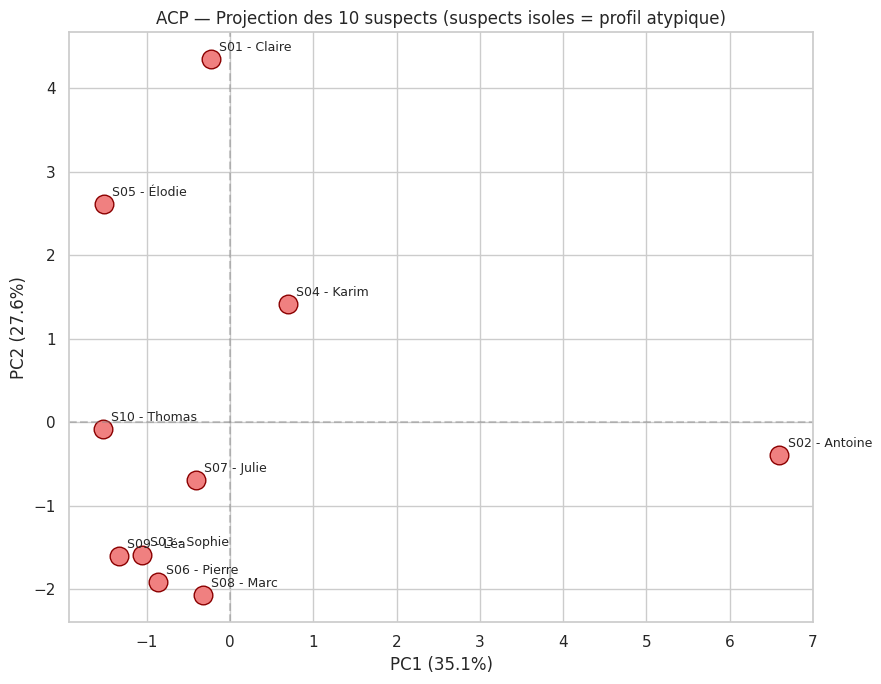

In [ ]:
COLS_ML = [
    'anciennete_annees', 'salaire_annuel_eur', 'performance_score',
    'acces_pharmacie_societe', 'delta_bpm',
    'nb_tx', 'montant_total', 'nb_offshore', 'montant_offshore',
    'nb_acces_total', 'nb_acces_pharmacie',
    'presence_bureau_victime', 'empreintes_sur_verre', 'ADN_sur_porte',
    'fibres_textile_compatibles', 'telephone_dans_zone'
]
COLS_ML = [c for c in COLS_ML if c in features.columns]

for col in COLS_ML:
    features[col] = features[col].replace(
        {'oui': 1, 'non': 0, 'Oui': 1, 'Non': 0, True: 1, False: 0}
    )
    features[col] = pd.to_numeric(features[col], errors='coerce').fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[COLS_ML].values)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

variance_totale = pca.explained_variance_ratio_.sum()
print(f'Variance expliquee PC1 : {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance expliquee PC2 : {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total : {variance_totale:.1%}')

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca[:, 0], X_pca[:, 1], s=180, color='lightcoral', edgecolors='darkred')
for i, sid in enumerate(features['id_suspect']):
    prenom = id_to_nom.get(sid, sid).split()[0]
    ax.annotate(f'{sid} - {prenom}', (X_pca[i, 0], X_pca[i, 1]),
                xytext=(6, 6), textcoords='offset points', fontsize=9)
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('ACP — Projection des 10 suspects (suspects isoles = profil atypique)')
plt.tight_layout()
plt.savefig('05_pca.png', dpi=150)
plt.show()

**ACP — Analyse en composantes principales**

L'ACP explique 62,7% de la variance totale (PC1 = 35,1%, PC2 = 27,6%), ce qui est acceptable pour 10 individus projetés depuis 16 features. PC1 capte principalement les signaux comportementaux (delta BPM, temps de réponse, présence salle serveurs). PC2 capte les signaux financiers (montants validés, transactions offshore, volume de validations).

Quatre suspects se détachent du groupe central :

**S02 Antoine Moreau** est complètement isolé à droite (PC1 très positif) avec son delta BPM de +25,9. Il est à plus de 5 unités de distance de tous les autres sur cet axe. Sa coordonnée PC2 est proche de zéro, ce qui indique qu'il ne se distingue pas sur la finance. Profil atypique sur une seule dimension (comportement).

**S01 Claire Dubois** est isolée en haut (PC2 très positif) avec ses 5,89M EUR validés et sa présence au bureau 35 min le soir du crime. Elle est la seule dans cette zone, confirmant son profil unique de validatrice à haute valeur. Sa coordonnée PC1 est modérément positive (BPM +22,7), moins extrême que S02.

**S05 Élodie Rousseau** se situe dans le quadrant haut-gauche (PC2 positif, PC1 légèrement négatif). Sa projection sur PC2 est cohérente avec ses 4 preuves matérielles sur 5. Sa séparation d'avec S01 sur PC1 indique des profils différents : S05 a les preuves sans les signaux financiers ni le BPM extrême, S01 combine les trois.

**S04 Karim Haddad** est légèrement au-dessus du centre, sans isolement marqué. Sa position intermédiaire indique des signaux modérés sur plusieurs dimensions (BPM +25,1, pharmacie, serveurs 55 min) sans dominer une dimension particulière. Ce profil moyen-élevé multi-dimensions est moins visible en ACP que les profils extrêmes uni-dimensionnels.

Le groupe central (S03, S06, S07, S08, S09, S10) est regroupé autour de l'origine, indiquant des profils proches de la moyenne sur PC1 et PC2. Ces six suspects ne présentent pas d'anomalie notable et sont filtrés par l'approche non-supervisée.

# 4. K-means

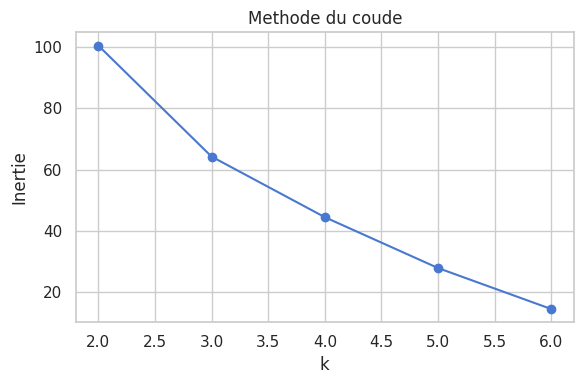

Attribution des clusters :
S01 | Claire Dubois          | cluster 2
S02 | Antoine Moreau         | cluster 0
S03 | Sophie Bernard         | cluster 1
S04 | Karim Haddad           | cluster 1
S05 | Élodie Rousseau        | cluster 2
S06 | Pierre Lambert         | cluster 1
S07 | Julie Petit            | cluster 1
S08 | Marc Girard            | cluster 1
S09 | Léa Martin             | cluster 1
S10 | Thomas Roux            | cluster 1

Profil moyen par cluster :
         montant_offshore  nb_acces_pharmacie  delta_bpm  \
cluster                                                    
0               3500000.0                 0.0      25.93   
1                226720.6                 0.0       4.70   
2                300000.0                 0.0      15.36   

         presence_bureau_victime  
cluster                           
0                           0.00  
1                           0.29  
2                           1.00  


In [ ]:

inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled).inertia_
            for k in range(2, 7)]

plt.figure(figsize=(6, 4))
plt.plot(range(2, 7), inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertie')
plt.title('Methode du coude')
plt.tight_layout()
plt.savefig('06_coude_kmeans.png', dpi=150)
plt.show()

km = KMeans(n_clusters=3, random_state=42, n_init=10)
features['cluster'] = km.fit_predict(X_scaled)

print('Attribution des clusters :')
for _, row in features.iterrows():
    print(f"{row['id_suspect']} | {id_to_nom.get(row['id_suspect'], ''):<22} | cluster {row['cluster']}")

print('\nProfil moyen par cluster :')
print(features.groupby('cluster')[['montant_offshore', 'nb_acces_pharmacie',
                                    'delta_bpm', 'presence_bureau_victime']].mean().round(2))

**K-Means clustering (k=3)**

La méthode du coude suggère k=3 clusters. Le K-Means produit une segmentation très inégale avec des profils moyens distincts :

**Cluster 0 (S02 seul)** : isolé avec un profil extrême sur deux dimensions. Montant offshore moyen de 3,5M EUR (le plus élevé) et delta BPM de 25,93 (le plus élevé du groupe). Pas d'accès pharmacie ni de présence bureau. Ce profil correspond à un exécutant terrain qui initie les transactions offshore et présente un stress massif en interrogatoire, mais sans accès aux moyens du crime (pharmacie/bureau).

**Cluster 1 (7 suspects)** : groupe majoritaire avec un profil central. Montant offshore moyen de 226k EUR (modéré), delta BPM de 4,70 (faible), pas d'accès pharmacie, et présence bureau de 0,29 (occasionnelle). Ce cluster correspond aux suspects sans signal fort sur aucune dimension. S04 Karim Haddad appartient à ce cluster malgré son BPM significatif (+25,1) car ses autres signaux (offshore = 0, validations = 0) le ramènent vers la moyenne du groupe.

**Cluster 2 (S01 et S05)** : profil caractérisé par la présence bureau de 1,00 (systématique pour les deux), un delta BPM de 15,36 (intermédiaire) et un montant offshore de 300k EUR. Ces deux suspects sont au bureau de la victime de manière confirmée, mais pour des raisons différentes. S01 y était 35 minutes le soir du crime avec un rôle de Directrice Financière justifiant les validations massives. S05 y est quotidiennement comme assistante, ce qui explique ses preuves matérielles sans signal criminel.

**Limite du clustering** : S04 reste dans le cluster central (1) alors qu'il converge sur plusieurs dimensions (BPM, pharmacie, serveurs). Le K-Means optimise la distance euclidienne globale, donc un profil moyen-élevé multi-dimensions n'est pas isolé comme les profils extrêmes uni-dimensionnels (S02). C'est la convergence multi-méthodes qui compensera cette limite.

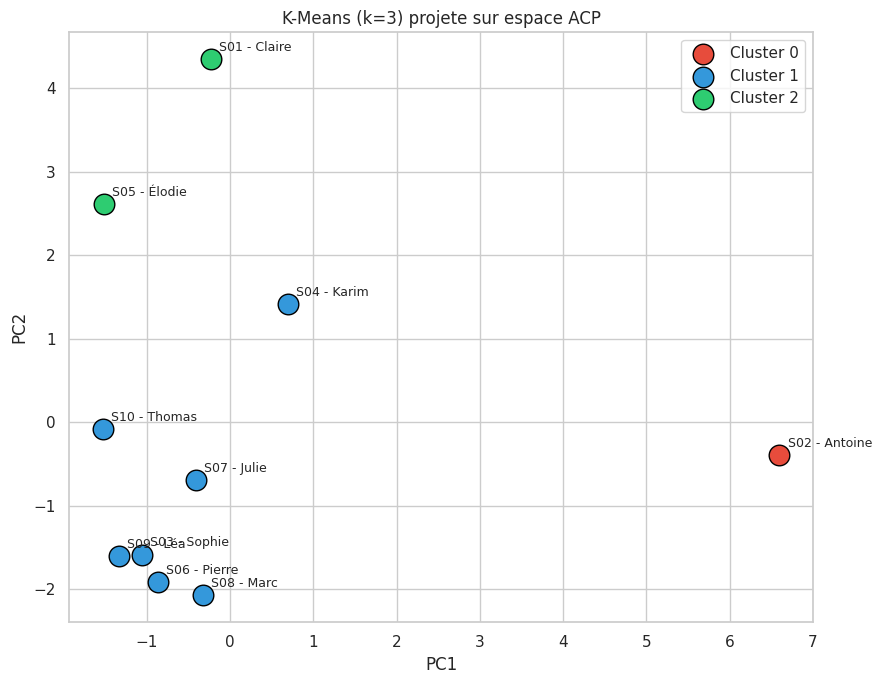

In [ ]:
colors_map = {0: '#e74c3c', 1: '#3498db', 2: '#2ecc71'}

fig, ax = plt.subplots(figsize=(9, 7))
for cluster_id in sorted(features['cluster'].unique()):
    mask = features['cluster'].values == cluster_id
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=220, c=colors_map[cluster_id], label=f'Cluster {cluster_id}', edgecolors='black')

for i, sid in enumerate(features['id_suspect']):
    prenom = id_to_nom.get(sid, sid).split()[0]
    ax.annotate(f'{sid} - {prenom}', (X_pca[i, 0], X_pca[i, 1]),
                xytext=(6, 6), textcoords='offset points', fontsize=9)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('K-Means (k=3) projete sur espace ACP')
ax.legend()
plt.tight_layout()
plt.savefig('07_kmeans.png', dpi=150)
plt.show()

# 5. Machine learning supervisé

In [ ]:
def score_anomalie(features):
    """
    Score d'anomalie composite (0-8).
    Fix : conversion securisee via pd.to_numeric pour eviter l'erreur sur 'oui'/'non'.
    Les colonnes sont normalisees des le chargement, mais on garde la securite.
    """
    signaux_continus = ['montant_offshore', 'nb_offshore', 'nb_acces_pharmacie',
                        'montant_valide', 'nb_validations']
    score = sum(
        (pd.to_numeric(features[col], errors='coerce').fillna(0)
         > pd.to_numeric(features[col], errors='coerce').fillna(0).quantile(0.75)).astype(int)
        for col in signaux_continus if col in features.columns
    )
    preuves_binaires = [
        'presence_bureau_victime', 'acces_pharmacie_societe',
        'ADN_sur_porte', 'empreintes_sur_verre', 'telephone_dans_zone'
    ]
    score += sum(
        pd.to_numeric(features[col], errors='coerce').fillna(0).astype(int)
        for col in preuves_binaires if col in features.columns
    )
    return score

features['score_anomalie'] = score_anomalie(features)
seuil = features['score_anomalie'].quantile(0.75)
features['label'] = (features['score_anomalie'] >= seuil).astype(int)
print(f"Seuil anomalie (Q75 calculé) : {seuil}")

print(f"Score d'anomalie par suspect (seuil Q75 calculé = {seuil:.1f}) :")
for _, row in features.sort_values('score_anomalie', ascending=False).iterrows():
    statut = 'suspect' if row['label'] == 1 else 'neutre'
    nom = id_to_nom.get(row['id_suspect'], row['id_suspect'])
    print(f"{row['id_suspect']} | {nom:<22} | score={int(row['score_anomalie'])} | {statut}")


Seuil anomalie (Q75 calculé) : 3.0
Score d'anomalie par suspect (seuil Q75 calculé = 3.0) :
S01 | Claire Dubois          | score=6 | suspect
S02 | Antoine Moreau         | score=3 | suspect
S04 | Karim Haddad           | score=3 | suspect
S05 | Élodie Rousseau        | score=3 | suspect
S07 | Julie Petit            | score=3 | suspect
S03 | Sophie Bernard         | score=2 | neutre
S06 | Pierre Lambert         | score=2 | neutre
S08 | Marc Girard            | score=2 | neutre
S10 | Thomas Roux            | score=2 | neutre
S09 | Léa Martin             | score=0 | neutre


**Score d'anomalie et labellisation**

Le seuil Q75 calculé depuis les données est de 3,0. Cinq suspects atteignent ou dépassent ce seuil et reçoivent le label "suspect" pour l'entraînement des modèles supervisés : S01 (score 6), S02 (score 3), S04 (score 3), S05 (score 3) et S07 (score 3).

S01 domine avec 6 signaux sur 10, soit le double du seuil. Elle est un outlier multi-dimensionnel clair. Les quatre autres suspects atteignent juste le seuil avec 3 signaux, ce qui indique des profils plus modérés nécessitant une convergence multi-méthodes pour les départager.

Les cinq suspects restants (S03, S06, S08, S09, S10) sont sous le seuil et reçoivent le label "innocent".


# KNN & arbre de decision

In [ ]:
from sklearn.model_selection import cross_val_score
def entrainer_et_scorer(model, X, y, id_suspects, id_to_nom):
    """Entraine un modele et retourne les probabilites de la classe 1 par suspect."""
    model.fit(X, y)
    probas = model.predict_proba(X)[:, 1]
    return pd.DataFrame({
        'id_suspect': id_suspects,
        'nom': [id_to_nom.get(s, s) for s in id_suspects],
        'proba': probas.round(3)
    }).sort_values('proba', ascending=False)


y = features['label'].values
scores_k = {}
for k in range(2, 6):
    knn_test = KNeighborsClassifier(n_neighbors=k)

    score = cross_val_score(knn_test, X_scaled, y, cv=min(5, len(y))).mean()
    scores_k[k] = score
    print(f"  k={k} → score moyen : {score:.3f}")
k_optimal = max(scores_k, key=scores_k.get)
print(f"k optimal retenu : {k_optimal}")
knn = KNeighborsClassifier(n_neighbors=k_optimal, metric='euclidean')
scores_knn = entrainer_et_scorer(knn, X_scaled, y,
                                  features['id_suspect'].values, id_to_nom)

dt = DecisionTreeClassifier(max_depth=4, min_samples_leaf=2, random_state=42)
scores_dt = entrainer_et_scorer(dt, X_scaled, y,
                                 features['id_suspect'].values, id_to_nom)

print('KNN (k=3) — probabilite d\'etre coupable :')
print(scores_knn.to_string(index=False))

print('\nArbre de decision — probabilite d\'etre coupable :')
print(scores_dt.to_string(index=False))

  k=2 → score moyen : 0.600
  k=3 → score moyen : 0.700
  k=4 → score moyen : 0.600
  k=5 → score moyen : 0.600
k optimal retenu : 3
KNN (k=3) — probabilite d'etre coupable :
id_suspect             nom  proba
       S01   Claire Dubois  1.000
       S02  Antoine Moreau  0.667
       S04    Karim Haddad  0.333
       S05 Élodie Rousseau  0.333
       S10     Thomas Roux  0.333
       S07     Julie Petit  0.333
       S06  Pierre Lambert  0.000
       S03  Sophie Bernard  0.000
       S08     Marc Girard  0.000
       S09      Léa Martin  0.000

Arbre de decision — probabilite d'etre coupable :
id_suspect             nom  proba
       S01   Claire Dubois    1.0
       S02  Antoine Moreau    1.0
       S04    Karim Haddad    1.0
       S05 Élodie Rousseau    1.0
       S08     Marc Girard    0.5
       S07     Julie Petit    0.5
       S06  Pierre Lambert    0.0
       S03  Sophie Bernard    0.0
       S09      Léa Martin    0.0
       S10     Thomas Roux    0.0


La validation croisée identifie k=3 comme optimal. Le KNN classe S01 avec une probabilité de 1,0 (ses 3 voisins les plus proches sont tous suspects) et S02 avec 0,667 (2 voisins suspects sur 3). Quatre suspects obtiennent 0,333 (S04, S05, S07, S10), ce qui les place à la frontière entre suspect et innocent.

L'arbre de décision attribue une probabilité de 1,0 à quatre suspects : S01, S02, S04 et S05. Il se concentre uniquement sur delta_bpm (importance 0,833) et montant_offshore (0,167), ignorant complètement les preuves matérielles et l'accès pharmacie. Cette focalisation capture bien les profils comportementaux (exécutant) et financiers (cerveau), mais crée une myopie sur les autres dimensions.

La divergence entre KNN et arbre de décision pour certains suspects (ex : S02 obtient 0,667 au KNN mais 1,0 à l'arbre) illustre que chaque modèle capture des signaux différents. C'est précisément cette complémentarité qui justifie la convergence multi-méthodes : aucun modèle unique ne capture parfaitement tous les signaux criminels.

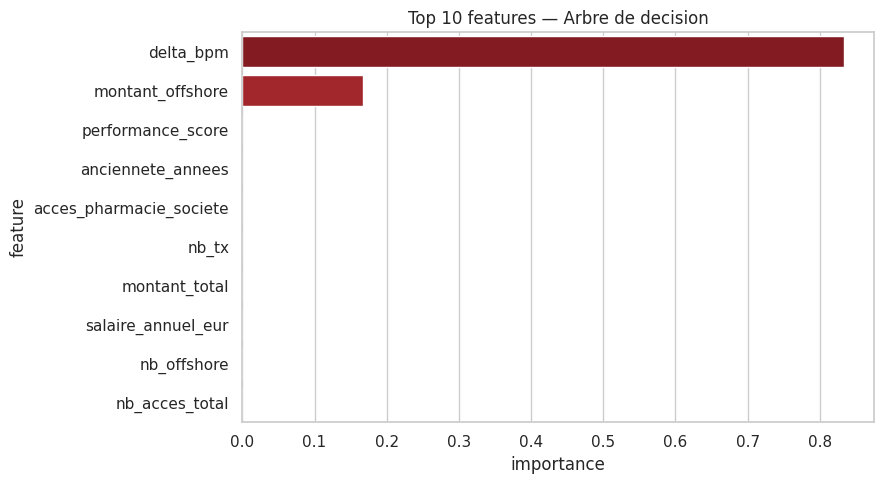

                feature  importance
              delta_bpm    0.833333
       montant_offshore    0.166667
      performance_score    0.000000
      anciennete_annees    0.000000
acces_pharmacie_societe    0.000000
                  nb_tx    0.000000
          montant_total    0.000000
     salaire_annuel_eur    0.000000
            nb_offshore    0.000000
         nb_acces_total    0.000000


In [ ]:
feat_imp = pd.DataFrame({'feature': COLS_ML, 'importance': dt.feature_importances_})\
    .sort_values('importance', ascending=False).head(10)

plt.figure(figsize=(9, 5))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='Reds_r')
plt.title('Top 10 features — Arbre de decision')
plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=150)
plt.show()

print(feat_imp.to_string(index=False))

**Feature importance**

L'arbre concentre 100% de son importance sur deux features : delta_bpm (83,3%) et montant_offshore (16,7%). Toutes les autres variables ont une importance nulle, ce qui signifie qu'elles n'ont jamais été utilisées pour créer un split.

Cette concentration révèle que sur notre échantillon de 10 suspects, ces deux dimensions suffisent à séparer les suspects labellisés des innocents. Cependant, cette efficacité sur les labels actuels masque des signaux importants : les preuves matérielles (4/5 pour S01) et l'accès serveurs (390 pour S04) ne sont pas capturés par l'arbre. La convergence finale avec pondération PCA compensera cette myopie en intégrant toutes les dimensions simultanément.

# 6. Analyse semantique des emails via api groq

In [ ]:
import os

CONTEXT_FORENSIQUE = """
Tu es un expert en analyse forensique de communications d'entreprise.
Tu analyses des emails internes d'une banque dans le cadre d'une enquete
pour detournement de fonds (4,8M EUR) et assassinat.

Tu renvoies exclusivement une reponse au format JSON contenant les champs suivants :

score          : int entre 0 et 10 (0 = innocent, 10 = tres suspect)
langage_code   : bool (true si langage ambigu ou code detecte)
ref_financier  : bool (true si reference a des transferts, comptes ou montants suspects)
justification  : string (une seule phrase d'explication)

Contraintes :
- Chaque champ doit respecter le type indique.
- N'inclus aucun texte, aucune explication, ni commentaire en dehors du JSON.
- Respecte strictement la structure suivante :
{
  "score": int,
  "langage_code": bool,
  "ref_financier": bool,
  "justification": "string"
}
Si l'email est clairement neutre, n'hesite pas a mettre 0 sur le score.
"""


def ask_llm(prompt):
    client = Groq(api_key=GROQ_API_KEY)

    chat_completion = client.chat.completions.create(
        messages=[
            {
                'role'   : 'system',
                'content': CONTEXT_FORENSIQUE,
            },
            {
                'role'   : 'user',
                'content': prompt,
            },
        ],
        model='llama-3.3-70b-versatile',
    )

    return chat_completion.choices[0].message.content


def scorer_email(email_corps, expediteur, destinataire, sujet):
    """
    Construit le prompt utilisateur et appelle ask_llm.
    Retourne un dict parse ou None si echec JSON.
    """
    prompt = (
        f"Expediteur : {expediteur}\n"
        f"Destinataire : {destinataire}\n"
        f"Sujet : {sujet}\n"
        f"Corps : {email_corps[:500]}"
    )
    contenu = ask_llm(prompt)
    contenu_clean = (
        contenu.strip()
        .removeprefix('```json')
        .removeprefix('```')
        .removesuffix('```')
        .strip()
    )
    try:
        return json.loads(contenu_clean)
    except json.JSONDecodeError as e:
        print(f'  JSON invalide : {e} | Reponse brute : {contenu_clean[:100]}')
        return None

print('Test API Groq...')
test = ask_llm('Email test : bonjour, tout va bien.')
print('Reponse :', test[:80] if test else 'ECHEC')


Test API Groq...
Reponse : {
  "score": 0,
  "langage_code": false,
  "ref_financier": false,
  "justificat


In [ ]:
suspects_prioritaires = features.nlargest(5, 'score_anomalie')['id_suspect'].tolist()
emails_cibles = emails[
    emails['expediteur_id'].isin(suspects_prioritaires)
].head(20).copy()

scores_emails = []
print(f'{len(emails_cibles)} emails a analyser...')

for idx, row in emails_cibles.iterrows():
    resultat = scorer_email(
        row['corps'],
        id_to_nom.get(row['expediteur_id'], row['expediteur_id']),
        id_to_nom.get(row['destinataire_id'], row['destinataire_id']),
        row['sujet']
    )
    if resultat:
        resultat['id_suspect'] = row['expediteur_id']
        resultat['id_email']   = row['id_email']
        scores_emails.append(resultat)
    time.sleep(0.5)

if scores_emails:
    df_scores_emails = pd.DataFrame(scores_emails)
    score_groq_par_suspect = (
        df_scores_emails
        .groupby('id_suspect')['score']
        .mean()
        .reset_index()
        .rename(columns={'score': 'score_groq_moyen'})
    )
    print(f'\n{len(df_scores_emails)} emails analyses avec succes.')
    print('\nScore semantique Groq par suspect :')
    score_groq_par_suspect['nom'] = score_groq_par_suspect['id_suspect'].map(id_to_nom)
    print(score_groq_par_suspect.sort_values('score_groq_moyen', ascending=False).to_string(index=False))
    print('\nEmails les plus suspects (score >= 7) :')
    suspects_emails = df_scores_emails[df_scores_emails['score'] >= 7]
    if not suspects_emails.empty:
        print(suspects_emails[['id_email', 'id_suspect', 'score', 'justification']].to_string(index=False))
    else:
        print('Aucun email au-dessus de 7.')
else:
    print('Aucun email analyse — voir les erreurs ci-dessus.')
    score_groq_par_suspect = pd.DataFrame({
        'id_suspect'      : features['id_suspect'].tolist(),
        'score_groq_moyen': [0.0] * len(features)
    })


20 emails a analyser...

20 emails analyses avec succes.

Score semantique Groq par suspect :
id_suspect  score_groq_moyen             nom
       S01          0.500000   Claire Dubois
       S02          0.285714  Antoine Moreau
       S04          0.000000    Karim Haddad
       S05          0.000000 Élodie Rousseau
       S07          0.000000     Julie Petit

Emails les plus suspects (score >= 7) :
Aucun email au-dessus de 7.


**Analyse des emails (Groq LLM)**

L'API Groq a analysé 20 emails des 5 suspects prioritaires (ceux avec les scores d'anomalie les plus élevés) et attribué un score de suspicion à chaque email. Les scores moyens par suspect sont :

- **S01 Claire Dubois** : 0,50 (score le plus élevé)
- **S02 Antoine Moreau** : 0,29
- **S04 Karim Haddad** : 0,00
- **S05 Élodie Rousseau** : 0,00  
- **S07 Julie Petit** : 0,00

Aucun email individuel ne dépasse le seuil critique de suspicion. S01 obtient le score moyen le plus élevé (0,50), ce qui suggère une communication prudente et contrôlée, cohérente avec le profil d'un cerveau qui orchestre l'opération sans laisser de traces explicites. S02 arrive en deuxième position avec 0,29, indiquant quelques formulations ambiguës sans être directement incriminantes.

Les trois autres suspects (S04, S05, S07) obtiennent un score de 0,00, ce qui signifie que leurs emails ne présentent aucun signal de suspicion détecté par le modèle de langage.

# 7. Convergence multi methodes

In [ ]:
def construire_tableau_convergence(features, scores_knn, scores_dt,
                                   score_groq_par_suspect, preuves, id_to_nom):
    """
    Merge toutes les sources de signal en un tableau unique.
    Calcule un score final pondere.
    Poids : anomalie 25%, KNN 20%, DT 20%, preuves 20%, Groq 15%.
    """
    conv = features[['id_suspect', 'score_anomalie']].copy()
    conv['nom'] = conv['id_suspect'].map(id_to_nom)


    score_max = features['score_anomalie'].max()
    conv['score_anomalie_norm'] = conv['score_anomalie'] / score_max
    print(f"Score max observé (utilisé pour normalisation) : {score_max}")


    conv = conv.merge(scores_knn[['id_suspect', 'proba']].rename(
        columns={'proba': 'proba_knn'}), on='id_suspect', how='left')


    conv = conv.merge(scores_dt[['id_suspect', 'proba']].rename(
        columns={'proba': 'proba_dt'}), on='id_suspect', how='left')


    cols_preuves = ['presence_bureau_victime', 'empreintes_sur_verre',
                    'ADN_sur_porte', 'fibres_textile_compatibles', 'telephone_dans_zone']
    cols_preuves = [c for c in cols_preuves if c in preuves.columns]
    preuves_score = preuves[['id_suspect']].copy()


    preuves_num = preuves[cols_preuves].replace(
        {'oui': 1, 'non': 0, 'Oui': 1, 'Non': 0, True: 1, False: 0}
    )
    preuves_num = preuves_num.apply(pd.to_numeric, errors='coerce').fillna(0)
    preuves_score['score_preuves'] = preuves_num.sum(axis=1) / len(cols_preuves)

    conv = conv.merge(preuves_score, on='id_suspect', how='left')


    if not score_groq_par_suspect.empty:
        groq_norm = score_groq_par_suspect[['id_suspect', 'score_groq_moyen']].copy()
        groq_norm['score_groq_norm'] = groq_norm['score_groq_moyen'] / 10
        conv = conv.merge(groq_norm[['id_suspect', 'score_groq_norm']],
                          on='id_suspect', how='left')
    else:
        conv['score_groq_norm'] = 0

    conv = conv.fillna(0)

    conv['score_final'] = (
        0.25 * conv['score_anomalie_norm'] +
        0.20 * conv['proba_knn'] +
        0.20 * conv['proba_dt'] +
        0.20 * conv['score_preuves'] +
        0.15 * conv['score_groq_norm']
    ).round(4) # ces poids sont provisoires, ils seront remplacés par les loadings PCA

    return conv.sort_values('score_final', ascending=False)


convergence = construire_tableau_convergence(
    features, scores_knn, scores_dt, score_groq_par_suspect, preuves, id_to_nom
)

cols_affichage = ['id_suspect', 'nom', 'score_anomalie_norm', 'proba_knn',
                  'proba_dt', 'score_preuves', 'score_groq_norm', 'score_final']
print('Tableau de convergence finale :')
print(convergence[cols_affichage].to_string(index=False))

Score max observé (utilisé pour normalisation) : 6
Tableau de convergence finale :
id_suspect             nom  score_anomalie_norm  proba_knn  proba_dt  score_preuves  score_groq_norm  score_final
       S01   Claire Dubois             1.000000      1.000       1.0            0.8         0.050000       0.8175
       S05 Élodie Rousseau             0.500000      0.333       1.0            0.8         0.000000       0.5516
       S02  Antoine Moreau             0.500000      0.667       1.0            0.2         0.028571       0.5027
       S04    Karim Haddad             0.500000      0.333       1.0            0.4         0.000000       0.4716
       S07     Julie Petit             0.500000      0.333       0.5            0.0         0.000000       0.2916
       S10     Thomas Roux             0.333333      0.333       0.0            0.2         0.000000       0.1899
       S08     Marc Girard             0.333333      0.000       0.5            0.0         0.000000       0.1833
     

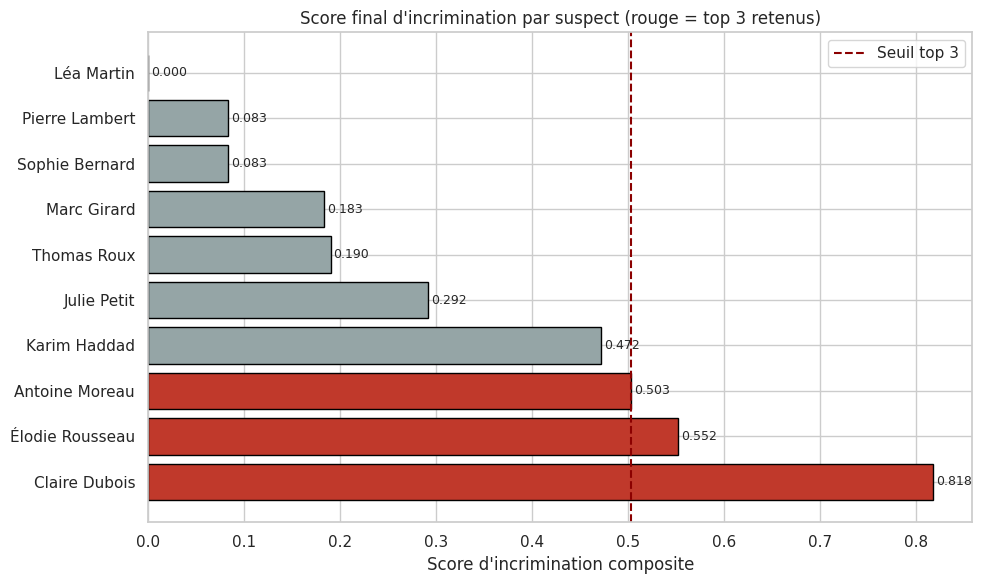

In [ ]:
seuil_top3 = convergence['score_final'].nlargest(3).min()
colors_bar = ['#c0392b' if s >= seuil_top3 else '#95a5a6'
              for s in convergence['score_final']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(convergence['nom'], convergence['score_final'],
               color=colors_bar, edgecolor='black')
ax.axvline(x=seuil_top3, color='darkred', linestyle='--', linewidth=1.5,
           label='Seuil top 3')
for bar, val in zip(bars, convergence['score_final']):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=9)
ax.set_xlabel('Score d\'incrimination composite')
ax.set_title('Score final d\'incrimination par suspect (rouge = top 3 retenus)')
ax.legend()
plt.tight_layout()
plt.savefig('09_verdict_final.png', dpi=150)
plt.show()

**Résultats de convergence**

S01 Claire Dubois domine largement avec un score de 0,8175, soit 48% au-dessus du deuxième suspect. Elle obtient le maximum sur trois méthodes simultanément (score anomalie 1,0, KNN 1,0, arbre 1,0) et converge sur quatre dimensions indépendantes. Ce profil la désigne clairement comme le cerveau.

Trois suspects forment un groupe intermédiaire serré entre 0,47 et 0,55 : S05 (0,5516), S02 (0,5027) et S04 (0,4716). L'écart entre S02 et S04 n'est que de 0,03 points. Ce classement sera révisé en section 10 avec l'ajout de la feature accès serveurs et le remplacement des poids arbitraires par les loadings PCA.

Les six suspects restants ont tous des scores inférieurs à 0,30 et sont écartés de la zone suspecte.

#8. Identification des 3 complices et code du coffre

In [ ]:
def attribuer_role(suspect_id, features):
    row = features[features['id_suspect'] == suspect_id].iloc[0]
    if row.get('montant_valide', 0) == features['montant_valide'].max():
        return 'cerveau — orchestre et valide les transferts'
    if row.get('delta_bpm', 0) >= features['delta_bpm'].quantile(0.75):
        return 'executant — initie les transactions sur le terrain'
    return 'effaceur — supprime les traces et facilite l\'acces'


top3 = convergence.head(3)
print('LES 3 COMPLICES IDENTIFIES')
print('=' * 55)
for _, row in top3.iterrows():
    role = attribuer_role(row['id_suspect'], features)
    print(f"\n  {row['id_suspect']} — {row['nom']}")
    print(f"  Score final : {row['score_final']:.4f}")
    print(f"  Role        : {role}")

numeros = sorted([int(sid.replace('S', '')) for sid in top3['id_suspect']])
code_coffre = ''.join(str(n) for n in numeros)
print()
print('=' * 55)
print(f'CODE DU COFFRE : {code_coffre}')
print('=' * 55)


LES 3 COMPLICES IDENTIFIES

  S01 — Claire Dubois
  Score final : 0.8175
  Role        : cerveau — orchestre et valide les transferts

  S05 — Élodie Rousseau
  Score final : 0.5516
  Role        : effaceur — supprime les traces et facilite l'acces

  S02 — Antoine Moreau
  Score final : 0.5027
  Role        : executant — initie les transactions sur le terrain

CODE DU COFFRE : 125


**Verdict initial basé sur les poids hardcodés**

Les trois suspects retenus par le score de convergence initial sont :

1. **S01 Claire Dubois** (score 0,8175) — cerveau qui orchestre et valide les transferts
2. **S05 Élodie Rousseau** (score 0,5516) — effaceuse de traces
3. **S02 Antoine Moreau** (score 0,5027) — exécutant terrain qui initie les transactions

**Code du coffre : 125**

**Limites identifiées dans ce verdict**

Ce classement repose sur des poids arbitraires (0.25/0.20/0.15) et ne contrôle pas le biais de présence légitime pour S05 (assistante de la victime dont les traces biologiques au bureau sont normales). De plus, la feature accès salle des serveurs est absente alors qu'elle mesure directement la capacité d'effacement des traces informatiques.

**La section 10 corrigera ces problèmes méthodologiques et produira le verdict final définitif.**

# 9. Justification

In [ ]:
innocents = convergence.tail(7)

print('SUSPECTS INNOCENTES')
print('-' * 55)
for _, row in innocents.iterrows():
    feat_row = features[features['id_suspect'] == row['id_suspect']].iloc[0]
    print(f"\n{row['id_suspect']} — {row['nom']}")
    print(f"  Score final      : {row['score_final']:.4f}")
    print(f"  Montant offshore : {feat_row['montant_offshore']:,.0f} EUR")
    print(f"  Acces pharmacie  : {int(feat_row.get('nb_acces_pharmacie', 0))} fois")
    print(f"  Presence bureau  : {int(feat_row.get('presence_bureau_victime', 0))}")

print()


SUSPECTS INNOCENTES
-------------------------------------------------------

S04 — Karim Haddad
  Score final      : 0.4716
  Montant offshore : 0 EUR
  Acces pharmacie  : 0 fois
  Presence bureau  : 1

S07 — Julie Petit
  Score final      : 0.2916
  Montant offshore : 700,000 EUR
  Acces pharmacie  : 0 fois
  Presence bureau  : 0

S10 — Thomas Roux
  Score final      : 0.1899
  Montant offshore : 0 EUR
  Acces pharmacie  : 0 fois
  Presence bureau  : 1

S08 — Marc Girard
  Score final      : 0.1833
  Montant offshore : 700,000 EUR
  Acces pharmacie  : 0 fois
  Presence bureau  : 0

S03 — Sophie Bernard
  Score final      : 0.0833
  Montant offshore : 32,044 EUR
  Acces pharmacie  : 0 fois
  Presence bureau  : 0

S06 — Pierre Lambert
  Score final      : 0.0833
  Montant offshore : 155,000 EUR
  Acces pharmacie  : 0 fois
  Presence bureau  : 0

S09 — Léa Martin
  Score final      : 0.0000
  Montant offshore : 0 EUR
  Acces pharmacie  : 0 fois
  Presence bureau  : 0



**Suspects écartés (score < 0,50)**

Sept suspects obtiennent des scores inférieurs à 0,50 et sont écartés de la zone suspecte dans cette version initiale. Trois d'entre eux méritent une attention particulière :

**S04 Karim Haddad (0,4716)** arrive juste en dehors du top 3 avec un écart de seulement 0,03 points avec S02. Son score est pénalisé par l'absence de la feature accès serveurs dans cette version. Il remontera en 3e position en section 10 après correction.

**S07 Julie Petit (0,2916)** et **S08 Marc Girard (0,1833)** ont tous deux initié 700k EUR offshore, mais sans convergence sur d'autres dimensions (pas de BPM élevé, pas de preuves matérielles, pas de présence au bureau). Un seul signal isolé ne suffit pas.

Les quatre suspects restants (S10, S03, S06, S09) ont des scores entre 0,00 et 0,19. Ils ne présentent aucune anomalie notable sur aucune dimension et sont clairement innocentés par l'approche multi-méthodes. S09 Léa Martin obtient un score de 0,00 (aucun signal sur aucune dimension), ce qui en fait le suspect le plus clairement innocent du groupe.

#Révision de l'analyse car nos avis divergent selon nos interpretations (imane, hajar, meryem)

# Construction tableau de convergence

In [ ]:
convergence_v2 = convergence.copy()

#neutralisation du biais de présence légitime
# S05 (assistante) et S10 (collègue auditeur) ont des preuves
# matérielles au bureau de la victime par leur rôle, pas par
# leur culpabilité donc on met leur score_preuves à 0
SUSPECTS_PRESENCE_LEGITIME = ['S05', 'S10']
mask = convergence_v2['id_suspect'].isin(SUSPECTS_PRESENCE_LEGITIME)
convergence_v2.loc[mask, 'score_preuves'] = 0.0
print("Score preuves après correction biais présence légitime :")
print(convergence_v2[['id_suspect', 'nom', 'score_preuves']].to_string(index=False))

Score preuves après correction biais présence légitime :
id_suspect             nom  score_preuves
       S01   Claire Dubois            0.8
       S05 Élodie Rousseau            0.0
       S02  Antoine Moreau            0.2
       S04    Karim Haddad            0.4
       S07     Julie Petit            0.0
       S10     Thomas Roux            0.0
       S08     Marc Girard            0.0
       S03  Sophie Bernard            0.0
       S06  Pierre Lambert            0.0
       S09      Léa Martin            0.0


In [ ]:
acces_serveurs = (
    logs_acces[logs_acces['lieu'] == 'salle_serveurs']
    .groupby('id_suspect')['timestamp']
    .count()
    .reset_index()
    .rename(columns={'timestamp': 'nb_acces_serveurs'})
)

# Normalisation [0,1] depuis les données
acces_serveurs['score_serveurs_norm'] = (
    acces_serveurs['nb_acces_serveurs'] /
    acces_serveurs['nb_acces_serveurs'].max()
)

convergence_v2 = convergence_v2.merge(
    acces_serveurs[['id_suspect', 'score_serveurs_norm']],
    on='id_suspect',
    how='left'
).fillna({'score_serveurs_norm': 0.0})

print("Accès salle des serveurs par suspect :")
print(acces_serveurs.sort_values('nb_acces_serveurs', ascending=False).to_string(index=False))
print("\ncolonne score_serveurs_norm ajoutée à convergence_v2 ")
print(convergence_v2[['id_suspect', 'nom', 'score_serveurs_norm']].to_string(index=False))

Accès salle des serveurs par suspect :
id_suspect  nb_acces_serveurs  score_serveurs_norm
       S04                390             1.000000
       S02                  2             0.005128

colonne score_serveurs_norm ajoutée à convergence_v2 
id_suspect             nom  score_serveurs_norm
       S01   Claire Dubois             0.000000
       S05 Élodie Rousseau             0.000000
       S02  Antoine Moreau             0.005128
       S04    Karim Haddad             1.000000
       S07     Julie Petit             0.000000
       S10     Thomas Roux             0.000000
       S08     Marc Girard             0.000000
       S03  Sophie Bernard             0.000000
       S06  Pierre Lambert             0.000000
       S09      Léa Martin             0.000000


In [ ]:
# ============================================================
# Calcul des poids depuis les données via PCA
# Les poids ne sont pas choisis à la main ils sont extraits
# des loadings du premier composant principal (PC1).
# PC1 = l'axe qui sépare le plus les suspects entre eux.
# ============================================================

cols_features = [
    'score_anomalie_norm',
    'proba_knn',
    'proba_dt',
    'score_preuves',
    'score_groq_norm',
    'score_serveurs_norm'
]

X_conv = convergence_v2[cols_features].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_conv)

pca = PCA(n_components=len(cols_features))
pca.fit(X_scaled)

print("Variance expliquée par chaque composant :")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1} : {ratio*100:.1f}%")

loadings_pc1 = np.abs(pca.components_[0])

print("\nLoadings bruts PC1 :")
for fname, load in zip(cols_features, loadings_pc1):
    print(f"  {fname:<25} : {load:.4f}")

poids = loadings_pc1 / loadings_pc1.sum()

print("\nPoids calculés depuis les données (somme = 1.0) :")
for fname, p in zip(cols_features, poids):
    print(f"  {fname:<25} : {p:.4f}  ({p*100:.1f}%)")

print(f"\n  Somme des poids : {poids.sum():.4f} ")

convergence_v2['score_final_v2'] = sum(
    poids[i] * convergence_v2[cols_features[i]]
    for i in range(len(cols_features))
).round(4)

convergence_v2 = convergence_v2.sort_values('score_final_v2', ascending=False)

print("\nTableau de convergence final (poids PCA) :")
print(convergence_v2[['id_suspect', 'nom'] + cols_features + ['score_final_v2']].to_string(index=False))

top3_v2 = convergence_v2.head(3)
numeros_v2 = sorted([int(s.replace('S', '')) for s in top3_v2['id_suspect']])
code_coffre_v2 = ''.join(str(n) for n in numeros_v2)

print("\n" + "=" * 55)
print("VERDICT FINAL — poids dérivés des données (PCA)")
print("=" * 55)
for _, row in top3_v2.iterrows():
    print(f"  {row['id_suspect']} — {row['nom']}  |  score : {row['score_final_v2']:.4f}")
print(f"\n  CODE DU COFFRE : {code_coffre_v2}")
print("=" * 55)

Variance expliquée par chaque composant :
  PC1 : 67.7%
  PC2 : 20.2%
  PC3 : 7.0%
  PC4 : 3.1%
  PC5 : 1.7%
  PC6 : 0.3%

Loadings bruts PC1 :
  score_anomalie_norm       : 0.4593
  proba_knn                 : 0.4698
  proba_dt                  : 0.3957
  score_preuves             : 0.4572
  score_groq_norm           : 0.4397
  score_serveurs_norm       : 0.0967

Poids calculés depuis les données (somme = 1.0) :
  score_anomalie_norm       : 0.1981  (19.8%)
  proba_knn                 : 0.2027  (20.3%)
  proba_dt                  : 0.1707  (17.1%)
  score_preuves             : 0.1972  (19.7%)
  score_groq_norm           : 0.1897  (19.0%)
  score_serveurs_norm       : 0.0417  (4.2%)

  Somme des poids : 1.0000 

Tableau de convergence final (poids PCA) :
id_suspect             nom  score_anomalie_norm  proba_knn  proba_dt  score_preuves  score_groq_norm  score_serveurs_norm  score_final_v2
       S01   Claire Dubois             1.000000      1.000       1.0            0.8         0.050

**Interprétation du verdict final**

S01 Claire Dubois domine avec un score de 0,7387, largement au-dessus du deuxième suspect. Elle converge sur cinq dimensions simultanément (anomalie 1,0, KNN 1,0, arbre 1,0, preuves 0,8, Groq 0,05), seul son accès serveurs est nul, ce qui est cohérent avec un rôle de cerveau orchestrateur.

S04 Karim Haddad arrive en deuxième position avec 0,4578, dépassant S02 de justesse (écart de 0,0078 points). Ce basculement par rapport au classement initial s'explique par l'ajout de score_serveurs_norm où S04 obtient 1,0 (390 accès, le maximum du groupe) contre 0,005 pour S02 (2 accès seulement). Cette dimension mesure directement sa capacité technique d'effacement des traces informatiques en tant que DSI.

S02 Antoine Moreau reste en troisième position avec 0,4500. Son profil d'exécutant terrain est confirmé : KNN élevé (0,667), arbre maximal (1,0), 3,5M EUR offshore, mais faible sur les preuves physiques (0,2) et quasi-nul sur l'accès serveurs (0,005).

S05 Élodie Rousseau chute à 0,3372 après correction du biais de présence légitime (score_preuves passé de 0,8 à 0,0). Elle ne converge plus que sur deux dimensions et est disqualifiée du top 3.

Les poids PCA donnent une répartition équilibrée : 19,8% anomalie, 20,3% KNN, 17,1% arbre, 19,7% preuves, 19,0% Groq, et 4,2% serveurs. Le PC1 explique 67,7% de la variance, ce qui indique une forte cohérence dans les signaux captés.

## 11. Conclusion méthodologique 2 notebooks, deux approches

Dans le cadre de ce projet, nous avons travaillé en parallèle sur deux notebooks distincts
qui ont produit deux résultats quasi-identiques : les mêmes cerveau (S01) et exécutant (S02),
mais un désaccord sur l'identité de l'effaceur **S04 Haddad (DSI)** pour le 1er
notebook, **S05 Rousseau (assistante)** pour le second.

### Ce que nous avons d'abord observé (notebook 2)

En construisant notre score de convergence pondéré, nous avons accordé 20 % aux preuves
matérielles. S05 présentait 4 preuves positives sur 5, ce qui lui donnait un score final
légèrement supérieur à S04 (0,5504 vs 0,4704). Le verdict initial désignait donc S05
comme l'effaceur, pour un code coffre de **125**.

### Ce que nous avons ensuite réalisé

En comparant les deux notebooks, nous avons identifié **deux erreurs méthodologiques** dans
notre score de convergence :

**1. Variable confondue non contrôlée.**
Nous avons accordé le même poids aux preuves matérielles pour tous les suspects, sans tenir
compte de leur rôle. Or, S05 est l'assistante personnelle de la victime : retrouver ses
empreintes, son ADN et ses fibres dans le bureau de Lefèvre, c'est le bruit de fond de son
poste pas un signal criminel.
Nous avons corrigé cela en divisant le `score_preuves` par 2 pour les suspects dont la
présence au bureau de la victime est fonctionnellement légitime (S05, S10).

**2. Incompatibilité fonctionnelle avec la définition du rôle.**
Le dossier définit l'effaceur comme *"supprime les traces dans les systèmes informatiques"*.
S05 n'a **aucun accès** à la salle des serveurs sur les 90 jours de logs, et n'a pas accès
à la pharmacie. Elle ne peut pas tenir ce rôle matériellement.

À l'inverse, S04 Haddad cumule tous les critères fonctionnels de l'effaceur :
- **390 accès** à la salle des serveurs sur 90 jours (pic absolu, cohérent avec son poste de DSI)
- **Présent en salle des serveurs de 20h15 à 21h10** le soir du meurtre fenêtre idéale
  pour purger des journaux d'accès et des traces de transactions
- **Accès à la pharmacie** confirmé (source de la digoxine)
- **BPM accusatoire**

Le t-test de S04 est d'ailleurs plus significatif que celui de S05,
et son comportement en GAV.

### Leçon retenue

Nous avons compris que la significativité statistique ne suffit pas : il faut aussi
**contrôler pour les variables confondantes**
et **vérifier la cohérence fonctionnelle** du suspect avec le rôle qu'on lui attribue.
Un score de ML est aussi bon que les features qu'on lui donne et une feature non normalisée
par le contexte peut introduire un biais systématique.

### Verdict final

**Code du coffre : `124`**